# Biểu đồ RMS Energy từ features_for_model.csv
Đoạn code dưới đây sẽ lấy giá trị RMS trung bình (rms_mean) và chuỗi RMS (nếu có) từ file features_for_model.csv để vẽ biểu đồ đúng với pipeline phân tích đặc trưng.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import numpy as np
import os

# Cấu hình đường dẫn
CSV_FEATURES = 'features_for_model.csv'
CSV_LYRICS = 'lyrics_extracted.csv'
AUDIO_PATH = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
SONG_NAME = "Qua Khung Cửa Sổ.mp3"

# 1. Đọc dữ liệu trực tiếp từ CSV (Tránh tính toán lại đặc trưng)
df_feat = pd.read_csv(CSV_FEATURES)
df_lyr = pd.read_csv(CSV_LYRICS)

# Gộp dữ liệu để phân tích tương quan
df_master = pd.merge(df_feat, df_lyr[['file_name', 'lyric']], on='file_name', how='inner')

print(f"✅ Đã tải dữ liệu cho {len(df_master)} bài hát.")
display(df_master[['file_name', 'rms_energy', 'tempo_bpm', 'sentiment_score']].head())

FileNotFoundError: [Errno 2] No such file or directory: 'features_for_model.csv'

Trực quan hóa RMS Energy cho "Qua Khung Cửa Sổ.mp3"


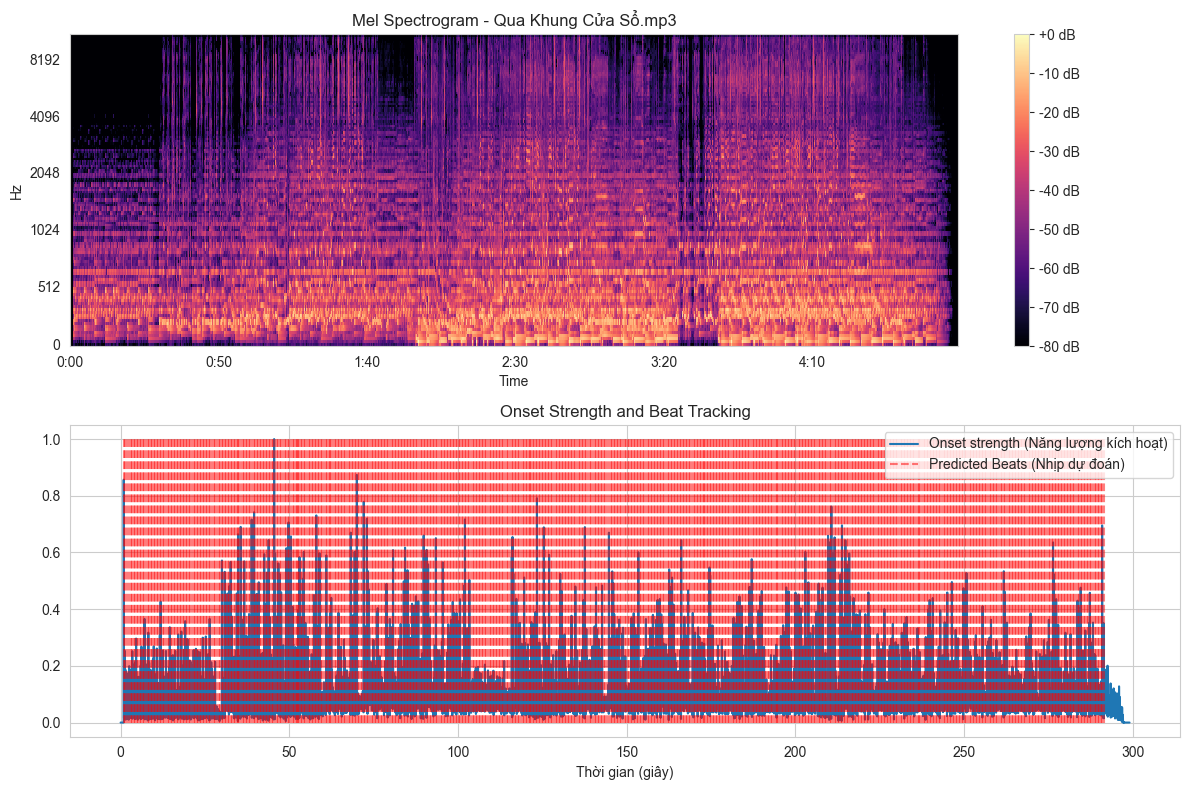

In [20]:
# Lưu ý: Phần này cần load file audio để vẽ phổ (không thể lấy từ CSV)
y, sr = librosa.load(AUDIO_PATH)

# Tính toán các thành phần cho biểu đồ chuẩn
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
beat_times = librosa.frames_to_time(beats, sr=sr)

# Vẽ biểu đồ 2 bảng (Subplots)
plt.figure(figsize=(12, 8))

# Panel 1: Mel Spectrogram
plt.subplot(2, 1, 1)
M = librosa.feature.melspectrogram(y=y, sr=sr)
librosa.display.specshow(librosa.power_to_db(M, ref=np.max),
                         y_axis='mel', x_axis='time', cmap='magma')
plt.title(f'Mel Spectrogram - {SONG_NAME}')
plt.colorbar(format='%+2.0f dB')

# Panel 2: Onset Strength & Predicted Beats
plt.subplot(2, 1, 2)
times = librosa.times_like(onset_env, sr=sr)
plt.plot(times, librosa.util.normalize(onset_env), label='Onset strength (Năng lượng kích hoạt)')
plt.vlines(beat_times, 0, 1, color='r', linestyle='--', alpha=0.5, label='Predicted Beats (Nhịp dự đoán)')
plt.title('Onset Strength and Beat Tracking')
plt.xlabel('Thời gian (giây)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
import os

# Xem Notebook đang đứng ở đâu
print("Thư mục hiện tại của Notebook:", os.getcwd())

# Liệt kê các file/folder có tại đây
print("Danh sách file/folder:", os.listdir())

Thư mục hiện tại của Notebook: d:\Hit_songs_DA\Audio_lyric
Danh sách file/folder: ['audio_final', 'bieudo.ipynb', 'extract_feature.py', 'extract_lyrics_from_mp3.py', 'features_for_model.csv', 'lyrics_extracted.csv', 'rms_only_qua_khung_cua_so.png']


Đang xử lý: audio_final\Qua Khung Cửa Sổ.mp3...


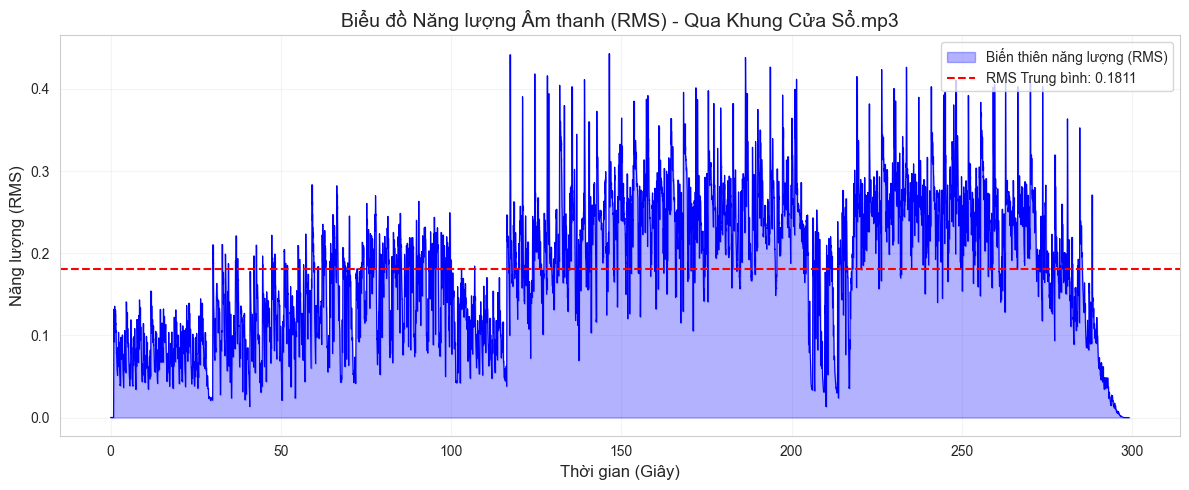

--- THÔNG SỐ RMS CỦA BÀI HÁT ---
Tên file: Qua Khung Cửa Sổ.mp3
Chỉ số RMS Energy trung bình: 0.181072


In [23]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Cấu hình đường dẫn
audio_path = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
csv_path = 'features_for_model.csv'

# 2. Lấy chỉ số RMS trung bình từ file CSV đã trích xuất
try:
    df = pd.read_csv(csv_path)
    song_data = df[df['file_name'] == 'Qua Khung Cửa Sổ.mp3']
    rms_mean_val = song_data['rms_energy'].values[0]
except:
    rms_mean_val = "Chưa có dữ liệu"

# 3. Tải file âm thanh và tính toán RMS theo thời gian
print(f"Đang xử lý: {audio_path}...")
y, sr = librosa.load(audio_path)

# Tính RMS cho từng khung hình (frame)
rms = librosa.feature.rms(y=y)[0]
times = librosa.times_like(rms, sr=sr)

# 4. Vẽ biểu đồ năng lượng duy nhất của bài hát
plt.figure(figsize=(12, 5))
plt.fill_between(times, rms, color='blue', alpha=0.3, label='Biến thiên năng lượng (RMS)')
plt.plot(times, rms, color='blue', linewidth=0.8)

# Vẽ đường trung bình (Chỉ số RMS của bài)
if isinstance(rms_mean_val, (float, int)):
    plt.axhline(y=rms_mean_val, color='red', linestyle='--', label=f'RMS Trung bình: {rms_mean_val:.4f}')

plt.title(f'Biểu đồ Năng lượng Âm thanh (RMS) - Qua Khung Cửa Sổ.mp3', fontsize=14)
plt.xlabel('Thời gian (Giây)', fontsize=12)
plt.ylabel('Năng lượng (RMS)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()

# Lưu biểu đồ ra file ảnh
plt.savefig('rms_only_qua_khung_cua_so.png')
plt.show()

print(f"--- THÔNG SỐ RMS CỦA BÀI HÁT ---")
print(f"Tên file: Qua Khung Cửa Sổ.mp3")
print(f"Chỉ số RMS Energy trung bình: {rms_mean_val}")

Đang phân tích năng lượng cho: audio_final\Qua Khung Cửa Sổ.mp3...


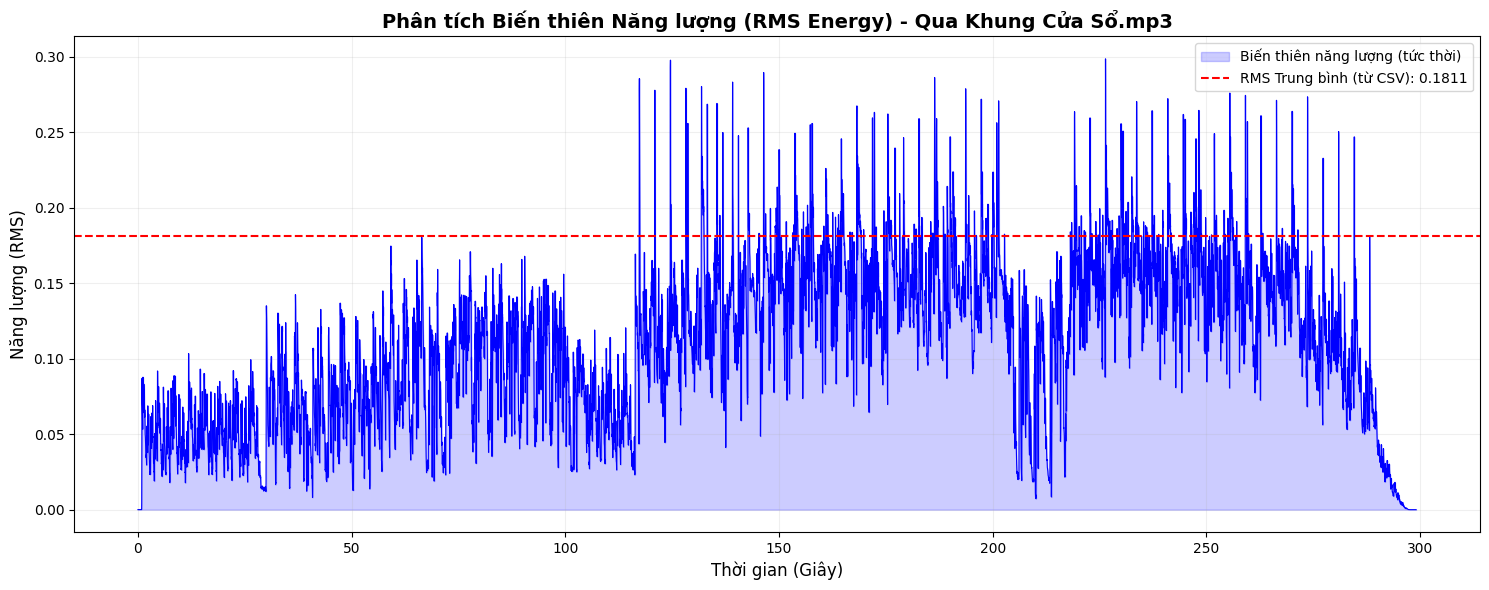

--- THÔNG SỐ RMS ---
Giá trị RMS trung bình trong dataset: 0.1811


In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Cấu hình đường dẫn
audio_path = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
csv_path = 'librosa_analysis.csv'

# 2. Tải dữ liệu từ CSV để lấy giá trị trung bình đối chiếu
df_audio = pd.read_csv(csv_path)
rms_mean_val = df_audio[df_audio['file_name'] == 'Qua Khung Cửa Sổ.mp3']['rms_energy'].values[0]

# 3. Chạy phân tích lại từ file MP3 để lấy dữ liệu thời gian thực
print(f"Đang phân tích năng lượng cho: {audio_path}...")
y, sr = librosa.load(audio_path)

# Tính RMS cho từng khung hình (frame)
# S: Phổ biên độ giúp tính toán RMS chính xác hơn theo chuẩn STFT
S, phase = librosa.magphase(librosa.stft(y))
rms = librosa.feature.rms(S=S)[0]
times = librosa.times_like(rms, sr=sr)

# 4. Vẽ biểu đồ RMS Energy chuẩn Documentation
plt.figure(figsize=(15, 6))

# Vẽ vùng năng lượng biến thiên
plt.fill_between(times, rms, color='blue', alpha=0.2, label='Biến thiên năng lượng (tức thời)')
plt.plot(times, rms, color='blue', linewidth=0.8)

# Vẽ đường RMS trung bình từ file CSV để đối chiếu
plt.axhline(y=rms_mean_val, color='red', linestyle='--', 
            label=f'RMS Trung bình (từ CSV): {rms_mean_val:.4f}')

# Tinh chỉnh biểu đồ
plt.title(f'Phân tích Biến thiên Năng lượng (RMS Energy) - Qua Khung Cửa Sổ.mp3', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giây)', fontsize=12)
plt.ylabel('Năng lượng (RMS)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()

# Lưu và hiển thị
plt.savefig('rms_energy_detail_analysis.png')
plt.show()

print(f"--- THÔNG SỐ RMS ---")
print(f"Giá trị RMS trung bình trong dataset: {rms_mean_val:.4f}")

Đang phân tích ZCR cho: audio_final\Qua Khung Cửa Sổ.mp3...


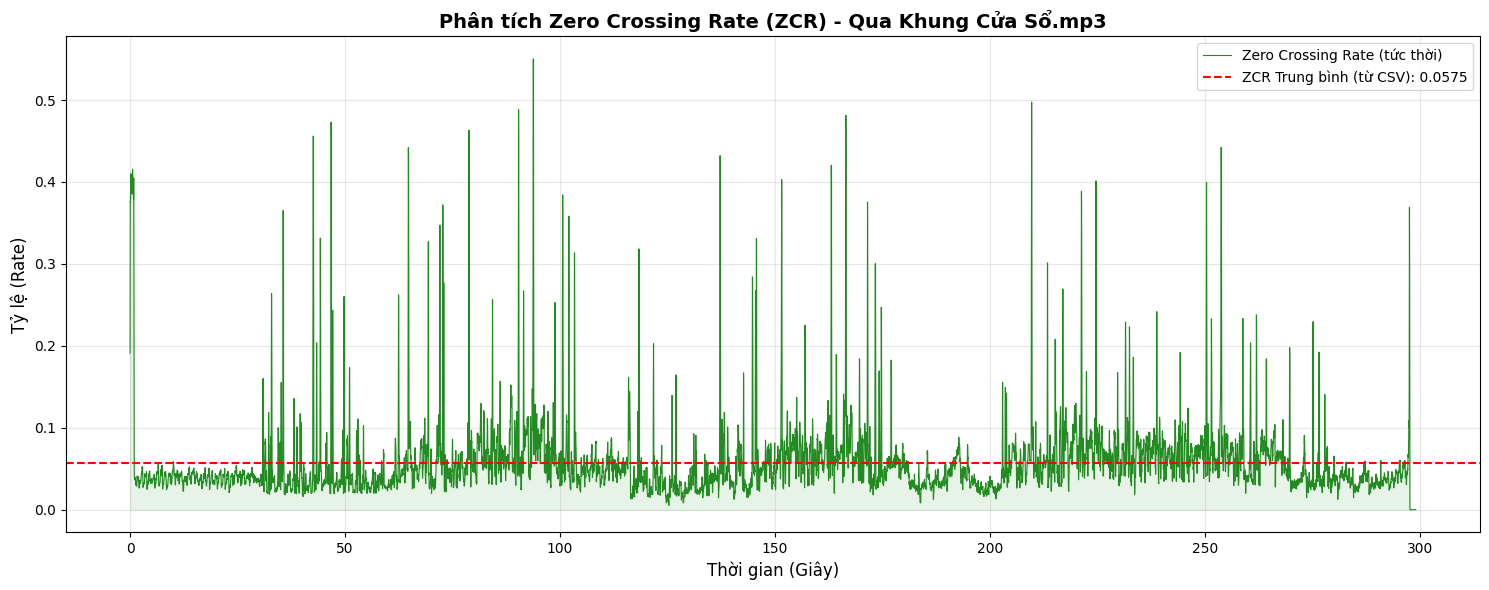

--- THÔNG SỐ ZCR ---
Giá trị ZCR trung bình trích xuất: 0.0575


In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Cấu hình đường dẫn
audio_path = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
csv_path = 'librosa_analysis.csv'

# 2. Tải dữ liệu từ CSV để lấy giá trị trung bình đối chiếu
df_audio = pd.read_csv(csv_path)
zcr_mean_val = df_audio[df_audio['file_name'] == 'Qua Khung Cửa Sổ.mp3']['zero_crossing_rate'].values[0]

# 3. Chạy phân tích lại từ file MP3 để lấy dữ liệu thời gian thực
print(f"Đang phân tích ZCR cho: {audio_path}...")
y, sr = librosa.load(audio_path)

# Tính toán Zero Crossing Rate cho từng khung hình
zcr = librosa.feature.zero_crossing_rate(y)[0]
times = librosa.times_like(zcr, sr=sr)

# 4. Vẽ biểu đồ ZCR theo chuẩn Librosa
plt.figure(figsize=(15, 6))

# Vẽ đường biến thiên ZCR
plt.plot(times, zcr, color='forestgreen', label='Zero Crossing Rate (tức thời)', linewidth=0.8)
plt.fill_between(times, zcr, color='forestgreen', alpha=0.1)

# Vẽ đường ZCR trung bình từ file CSV để đối chiếu
plt.axhline(y=zcr_mean_val, color='red', linestyle='--', 
            label=f'ZCR Trung bình (từ CSV): {zcr_mean_val:.4f}')

# Tinh chỉnh biểu đồ
plt.title(f'Phân tích Zero Crossing Rate (ZCR) - Qua Khung Cửa Sổ.mp3', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giây)', fontsize=12)
plt.ylabel('Tỷ lệ (Rate)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

# Lưu và hiển thị
plt.savefig('zcr_detail_analysis.png')
plt.show()

print(f"--- THÔNG SỐ ZCR ---")
print(f"Giá trị ZCR trung bình trích xuất: {zcr_mean_val:.4f}")

Đang phân tích Spectral Centroid cho: audio_final\Qua Khung Cửa Sổ.mp3...


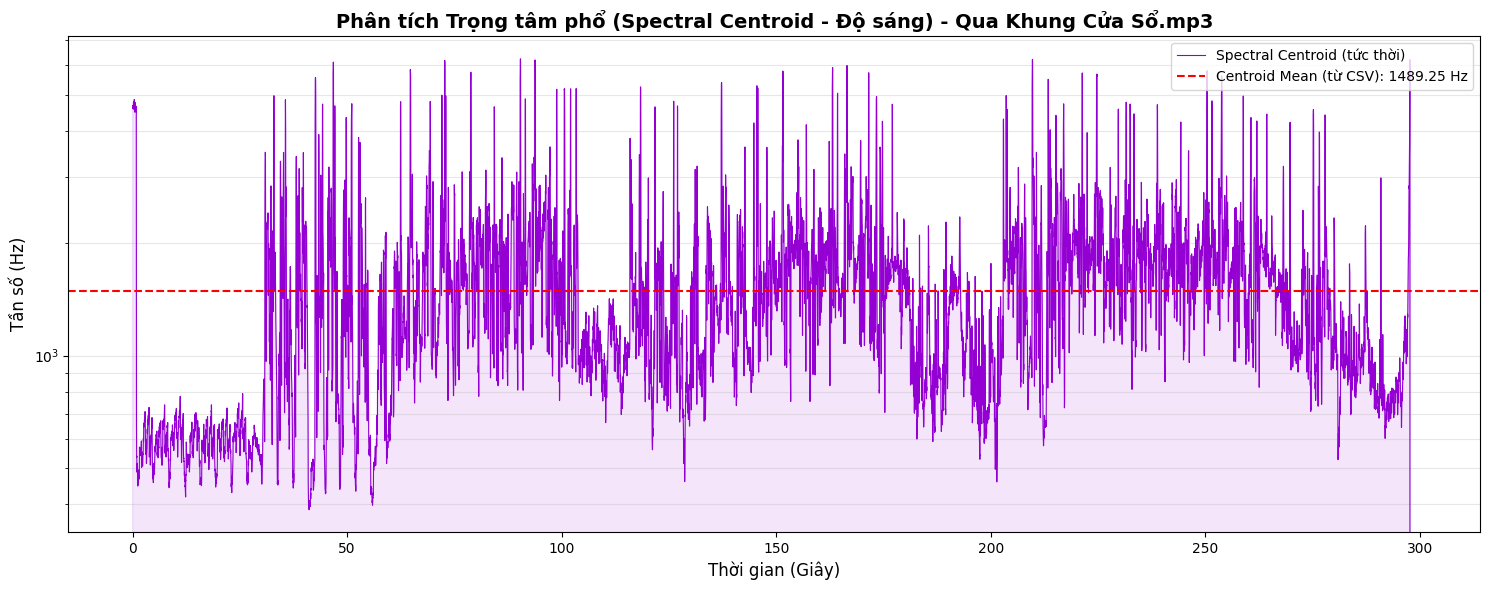

--- THÔNG SỐ SPECTRAL CENTROID ---
Giá trị Trọng tâm phổ trung bình: 1489.25 Hz


In [11]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Cấu hình đường dẫn
audio_path = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
csv_path = 'librosa_analysis.csv'

# 2. Tải dữ liệu từ CSV để lấy giá trị trung bình đối chiếu
df_audio = pd.read_csv(csv_path)
centroid_mean_val = df_audio[df_audio['file_name'] == 'Qua Khung Cửa Sổ.mp3']['spectral_centroid_mean'].values[0]

# 3. Chạy phân tích lại từ file MP3 để lấy dữ liệu thời gian thực
print(f"Đang phân tích Spectral Centroid cho: {audio_path}...")
y, sr = librosa.load(audio_path)

# Tính toán Spectral Centroid cho từng khung hình
cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
times = librosa.times_like(cent)

# 4. Vẽ biểu đồ Spectral Centroid theo chuẩn Documentation
plt.figure(figsize=(15, 6))

# Vẽ đường biến thiên trọng tâm phổ (sử dụng thang đo log cho trục Y để khớp cảm thụ tai người)
plt.semilogy(times, cent, color='darkviolet', label='Spectral Centroid (tức thời)', linewidth=0.8)
plt.fill_between(times, cent, color='darkviolet', alpha=0.1)

# Vẽ đường trung bình từ file CSV để đối chiếu
plt.axhline(y=centroid_mean_val, color='red', linestyle='--', 
            label=f'Centroid Mean (từ CSV): {centroid_mean_val:.2f} Hz')

# Tinh chỉnh biểu đồ
plt.title(f'Phân tích Trọng tâm phổ (Spectral Centroid - Độ sáng) - Qua Khung Cửa Sổ.mp3', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giây)', fontsize=12)
plt.ylabel('Tần số (Hz)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(which='both', axis='y', alpha=0.3)
plt.tight_layout()

# Lưu và hiển thị
plt.savefig('spectral_centroid_detail.png')
plt.show()

print(f"--- THÔNG SỐ SPECTRAL CENTROID ---")
print(f"Giá trị Trọng tâm phổ trung bình: {centroid_mean_val:.2f} Hz")

Đang phân tích Spectral Rolloff cho: audio_final\Qua Khung Cửa Sổ.mp3...


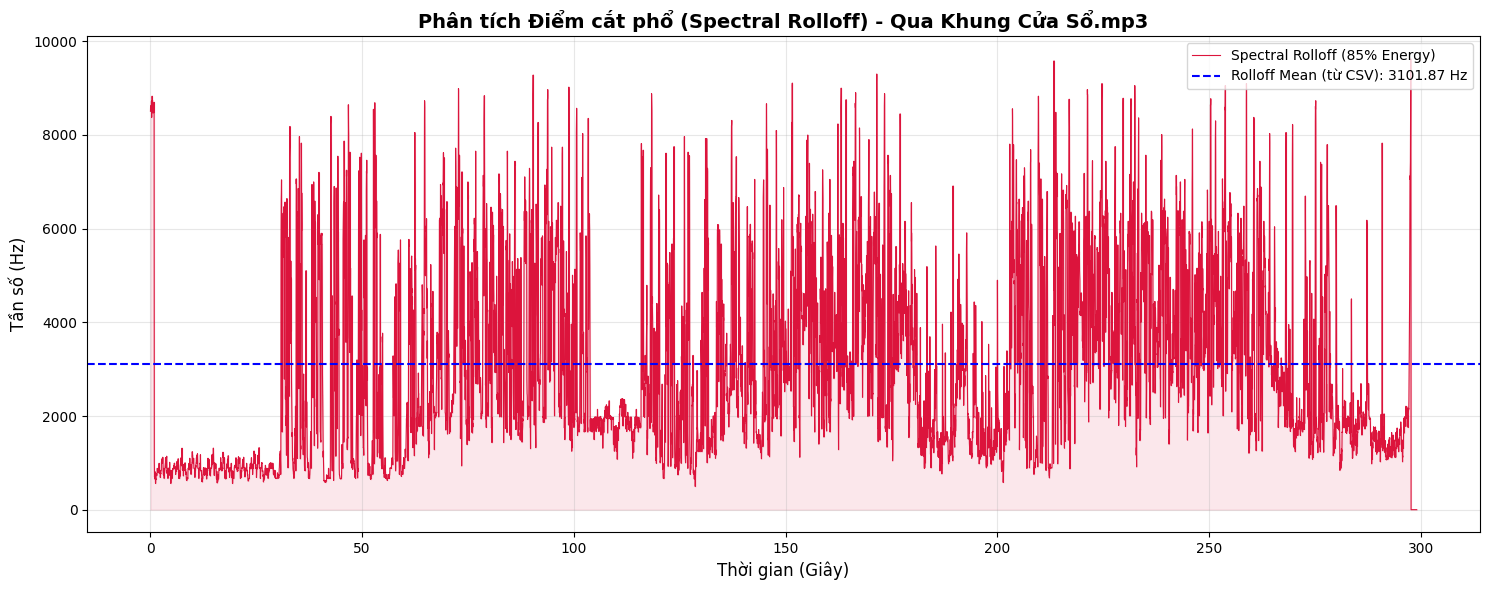

--- THÔNG SỐ SPECTRAL ROLLOFF ---
Giá trị trung bình (85% năng lượng): 3101.87 Hz


In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Cấu hình đường dẫn
audio_path = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
csv_path = 'librosa_analysis.csv'

# 2. Lấy giá trị trung bình từ CSV để đối chiếu
df_audio = pd.read_csv(csv_path)
rolloff_mean_val = df_audio[df_audio['file_name'] == 'Qua Khung Cửa Sổ.mp3']['spectral_rolloff'].values[0]

# 3. Chạy phân tích lại từ file MP3
print(f"Đang phân tích Spectral Rolloff cho: {audio_path}...")
y, sr = librosa.load(audio_path)

# Tính toán Spectral Rolloff (mặc định roll_percent=0.85)
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
times = librosa.times_like(rolloff, sr=sr)

# 4. Vẽ biểu đồ chuẩn Documentation
plt.figure(figsize=(15, 6))

# Vẽ đường biến thiên Rolloff
plt.plot(times, rolloff, color='crimson', label='Spectral Rolloff (85% Energy)', linewidth=0.8)
plt.fill_between(times, rolloff, color='crimson', alpha=0.1)

# Vẽ đường trung bình từ file CSV để đối chiếu
plt.axhline(y=rolloff_mean_val, color='blue', linestyle='--', 
            label=f'Rolloff Mean (từ CSV): {rolloff_mean_val:.2f} Hz')

# Tinh chỉnh biểu đồ
plt.title(f'Phân tích Điểm cắt phổ (Spectral Rolloff) - Qua Khung Cửa Sổ.mp3', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giây)', fontsize=12)
plt.ylabel('Tần số (Hz)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

# Lưu và hiển thị
plt.savefig('spectral_rolloff_detail.png')
plt.show()

print(f"--- THÔNG SỐ SPECTRAL ROLLOFF ---")
print(f"Giá trị trung bình (85% năng lượng): {rolloff_mean_val:.2f} Hz")

Đang phân tích Spectral Contrast cho: audio_final\Qua Khung Cửa Sổ.mp3...


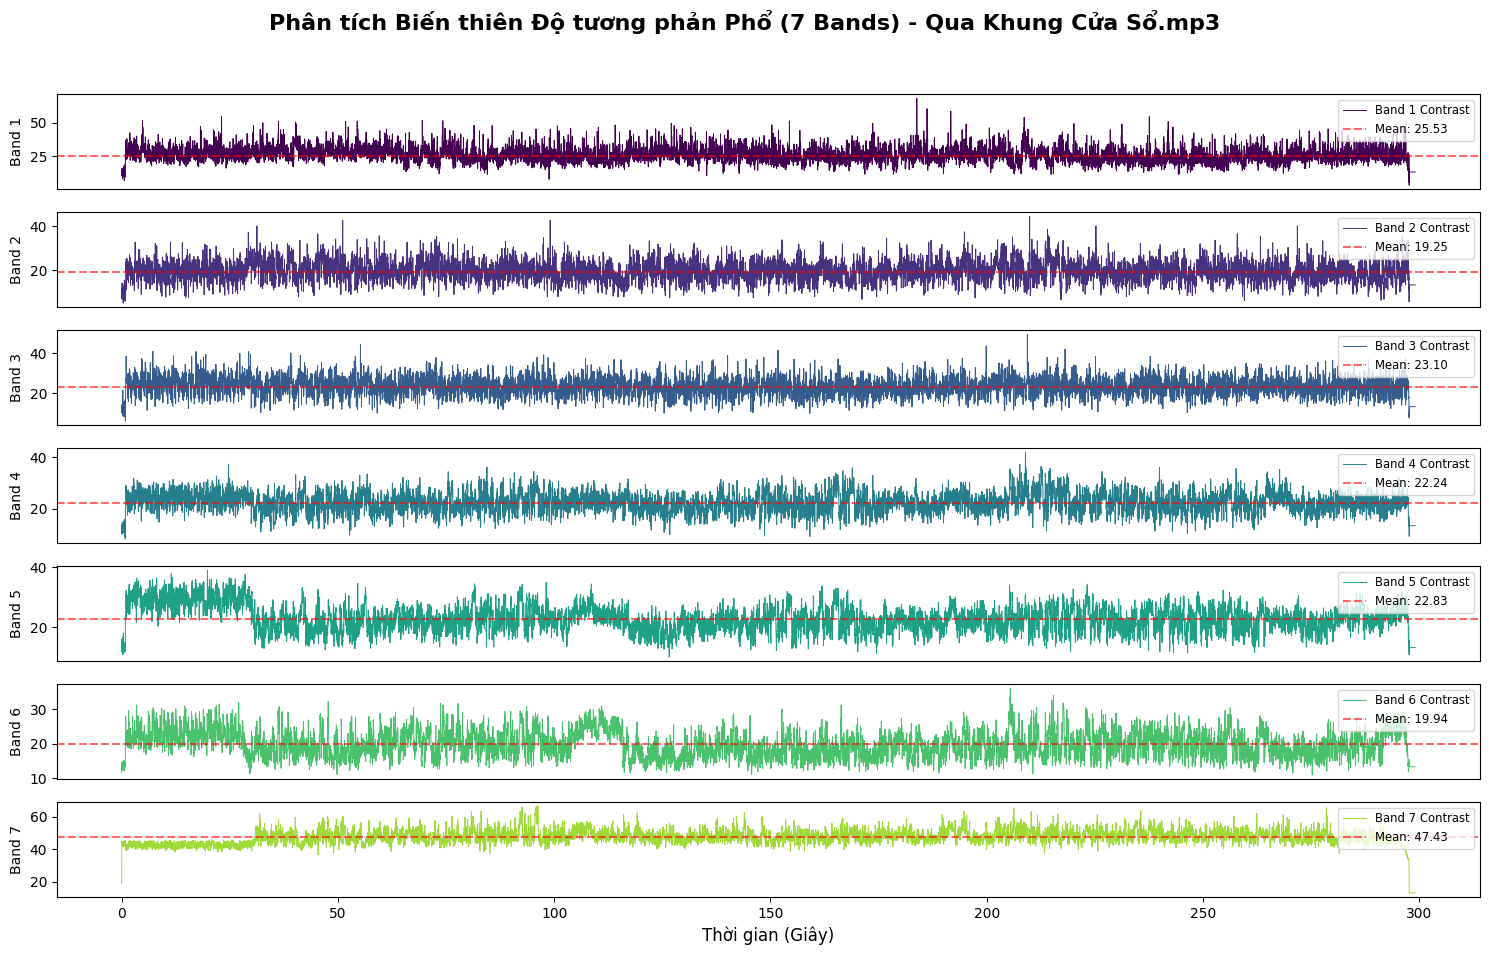

--- THÔNG SỐ SPECTRAL CONTRAST TRUNG BÌNH ---
Band 1 Mean: 25.53
Band 2 Mean: 19.25
Band 3 Mean: 23.10
Band 4 Mean: 22.24
Band 5 Mean: 22.83
Band 6 Mean: 19.94
Band 7 Mean: 47.43


In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Cấu hình đường dẫn
audio_path = os.path.join('audio_final', 'Qua Khung Cửa Sổ.mp3')
csv_path = 'librosa_analysis.csv'

# 2. Lấy các giá trị trung bình từ CSV để đối chiếu (7 dải)
df_audio = pd.read_csv(csv_path)
song_data = df_audio[df_audio['file_name'] == 'Qua Khung Cửa Sổ.mp3'].iloc[0]
contrast_means = [song_data[f'spectral_contrast_band{i+1}_mean'] for i in range(7)]

# 3. Chạy phân tích lại từ file MP3
print(f"Đang phân tích Spectral Contrast cho: {audio_path}...")
y, sr = librosa.load(audio_path)

# Tính toán Spectral Contrast (mặc định trả về 7 dải tương ứng với các quãng octave)
S = np.abs(librosa.stft(y))
contrast = librosa.feature.spectral_contrast(S=S, sr=sr)
times = librosa.times_like(contrast, sr=sr)

# 4. Vẽ biểu đồ phân tích chi tiết (7 dải tần số)
plt.figure(figsize=(15, 10))

for i in range(7):
    plt.subplot(7, 1, i+1)
    # Vẽ biến thiên tức thời
    plt.plot(times, contrast[i], label=f'Band {i+1} Contrast', color=plt.cm.viridis(i/7), linewidth=0.7)
    # Vẽ đường trung bình từ CSV
    plt.axhline(y=contrast_means[i], color='red', linestyle='--', alpha=0.6, 
                label=f'Mean: {contrast_means[i]:.2f}')
    
    plt.ylabel(f'Band {i+1}')
    plt.legend(loc='upper right', fontsize='small')
    if i < 6:
        plt.xticks([]) # Ẩn trục X cho các biểu đồ trên

plt.suptitle(f'Phân tích Biến thiên Độ tương phản Phổ (7 Bands) - Qua Khung Cửa Sổ.mp3', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian (Giây)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Lưu và hiển thị
plt.savefig('spectral_contrast_detail_7bands.png')
plt.show()

print("--- THÔNG SỐ SPECTRAL CONTRAST TRUNG BÌNH ---")
for i, val in enumerate(contrast_means):
    print(f"Band {i+1} Mean: {val:.2f}")

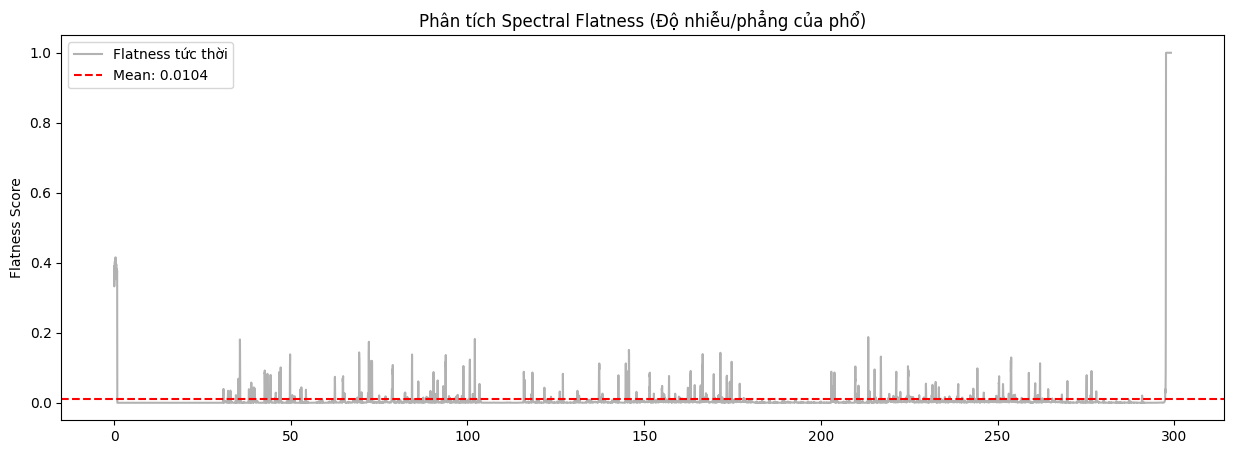

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Nạp file và dữ liệu CSV
y, sr = librosa.load('audio_final/Qua Khung Cửa Sổ.mp3')
df = pd.read_csv('librosa_analysis.csv')
mean_val = df[df['file_name'] == 'Qua Khung Cửa Sổ.mp3']['spectral_flatness_mean'].values[0]

# Tính toán tức thời
flatness = librosa.feature.spectral_flatness(y=y)[0]
times = librosa.times_like(flatness)

plt.figure(figsize=(15, 5))
plt.plot(times, flatness, color='gray', label='Flatness tức thời', alpha=0.6)
plt.axhline(y=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
plt.title('Phân tích Spectral Flatness (Độ nhiễu/phẳng của phổ)')
plt.ylabel('Flatness Score')
plt.legend()
plt.show()

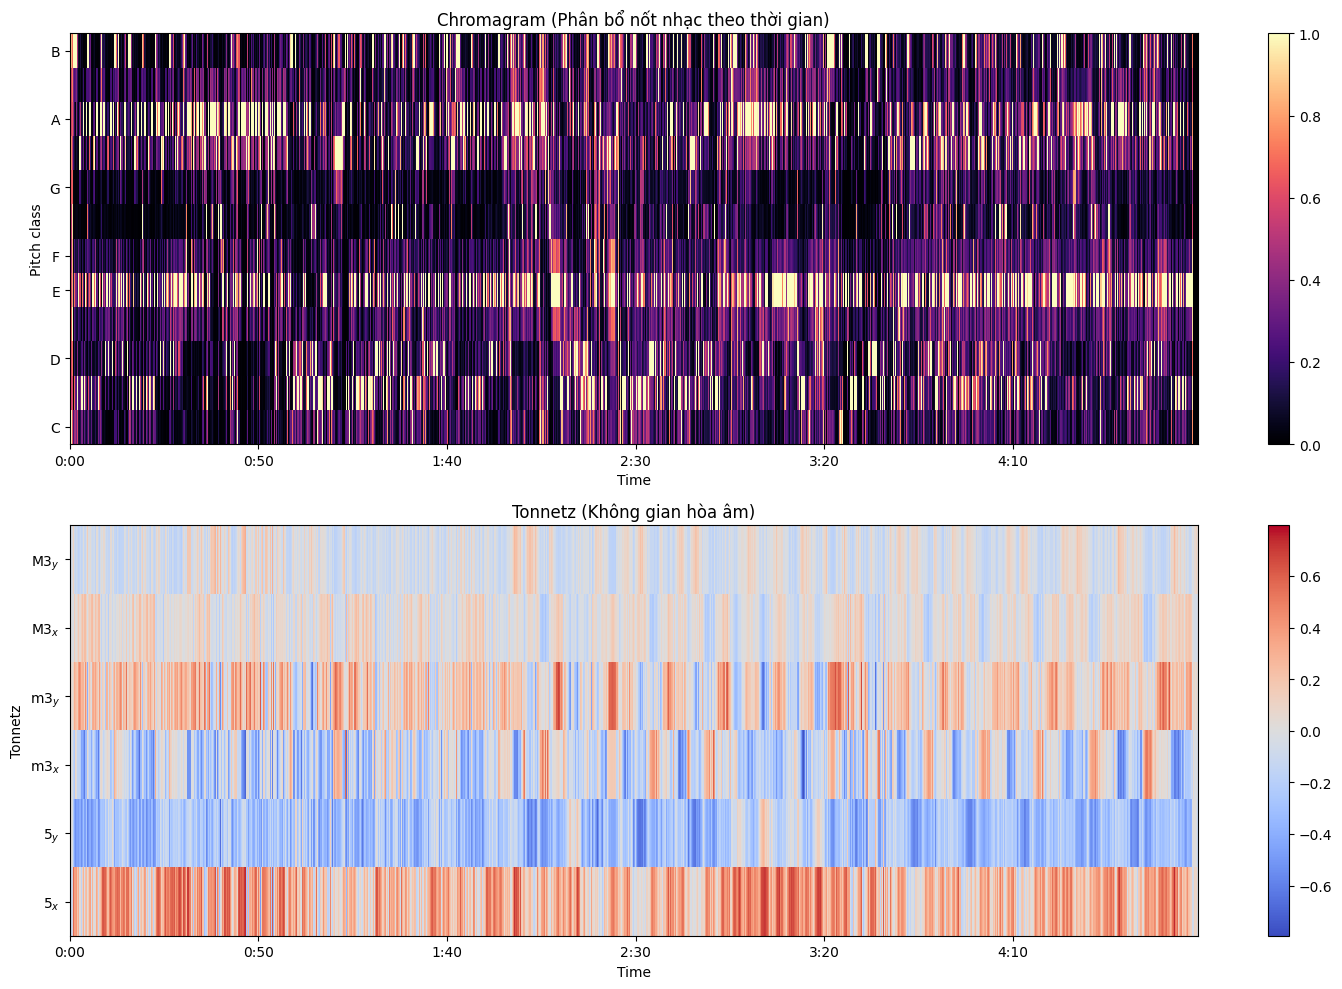

In [16]:
# Chroma
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
# Tonnetz
tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)

fig, ax = plt.subplots(2, 1, figsize=(15, 10))
img1 = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[0])
ax[0].set(title='Chromagram (Phân bổ nốt nhạc theo thời gian)')
fig.colorbar(img1, ax=ax[0])

img2 = librosa.display.specshow(tonnetz, y_axis='tonnetz', x_axis='time', ax=ax[1])
ax[1].set(title='Tonnetz (Không gian hòa âm)')
fig.colorbar(img2, ax=ax[1])
plt.tight_layout()
plt.show()

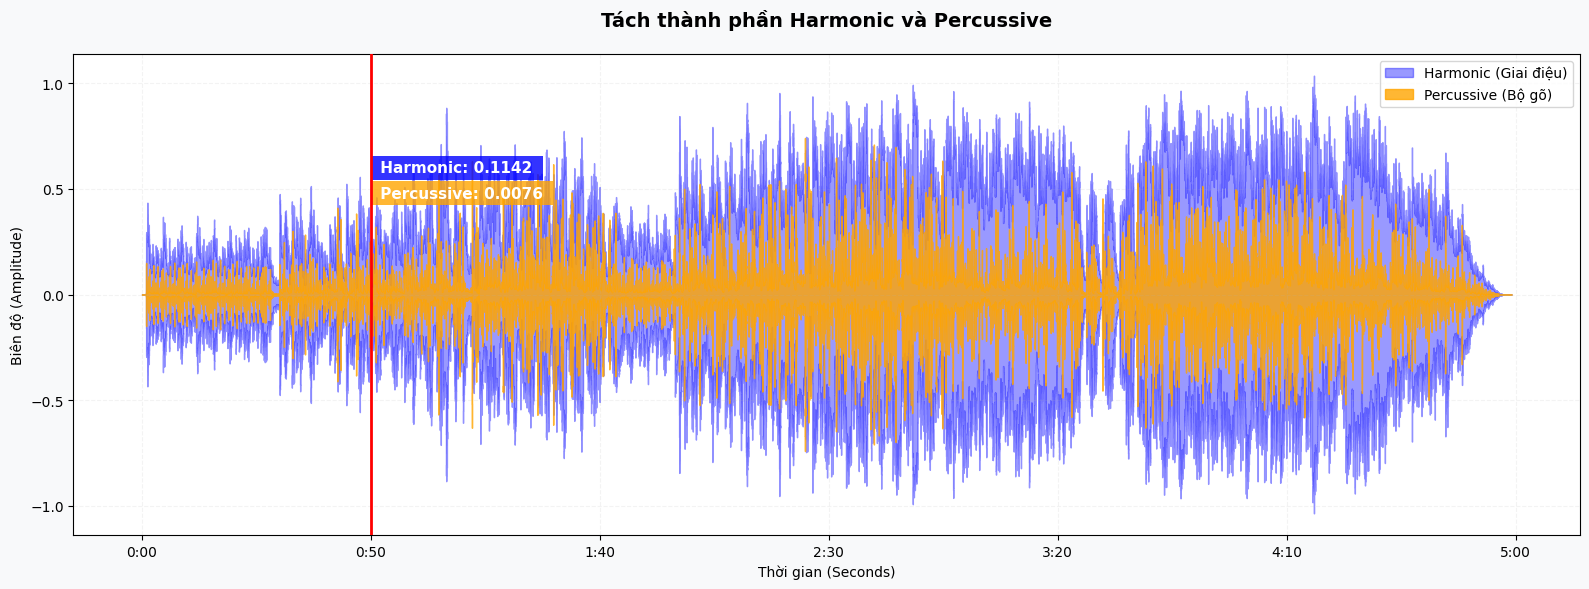

In [13]:
import matplotlib.pyplot as plt
import librosa.display

# Giữ nguyên màu sắc truyền thống theo yêu cầu của bạn
color_h = 'blue'    # Harmonic - Giai điệu
color_p = 'orange'  # Percussive - Bộ gõ
color_line = 'red'  # Vạch chỉ định

plt.figure(figsize=(16, 6), facecolor='#F8F9FA')

# Vẽ sóng Harmonic và Percussive 
librosa.display.waveshow(y_harmonic, sr=sr, alpha=0.4, label='Harmonic (Giai điệu)', color=color_h)
librosa.display.waveshow(y_percussive, sr=sr, alpha=0.8, label='Percussive (Bộ gõ)', color=color_p)

# Thanh gạch đỏ sắc nét tại giây 50 [cite: 43]
plt.axvline(x=50, color=color_line, linestyle='-', linewidth=2, zorder=10)

# --- HIỂN THỊ GIÁ TRỊ TẠI 0:50 (DÙNG TEXT BOX GỌN GÀNG) ---
# Đặt chữ sát vạch đỏ, lệch sang phải một chút (x=51) để không đè lên vạch
common_style = dict(fontweight='bold', color='white', fontsize=11)

# Nhãn cho Harmonic (0.1142) [cite: 336]
plt.text(51, 0.6, f' Harmonic: {0.1142} ', va='center', 
         bbox=dict(boxstyle="square,pad=0.3", fc=color_h, ec="none", alpha=0.8), **common_style)

# Nhãn cho Percussive (0.0076) [cite: 337]
plt.text(51, 0.48, f' Percussive: {0.0076} ', va='center', 
         bbox=dict(boxstyle="square,pad=0.3", fc=color_p, ec="none", alpha=0.8), **common_style)

# Tinh chỉnh giao diện 
plt.title('Tách thành phần Harmonic và Percussive', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Thời gian (Seconds)', fontsize=10)
plt.ylabel('Biên độ (Amplitude)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.15) # Lưới siêu mờ cho sạch biểu đồ
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()


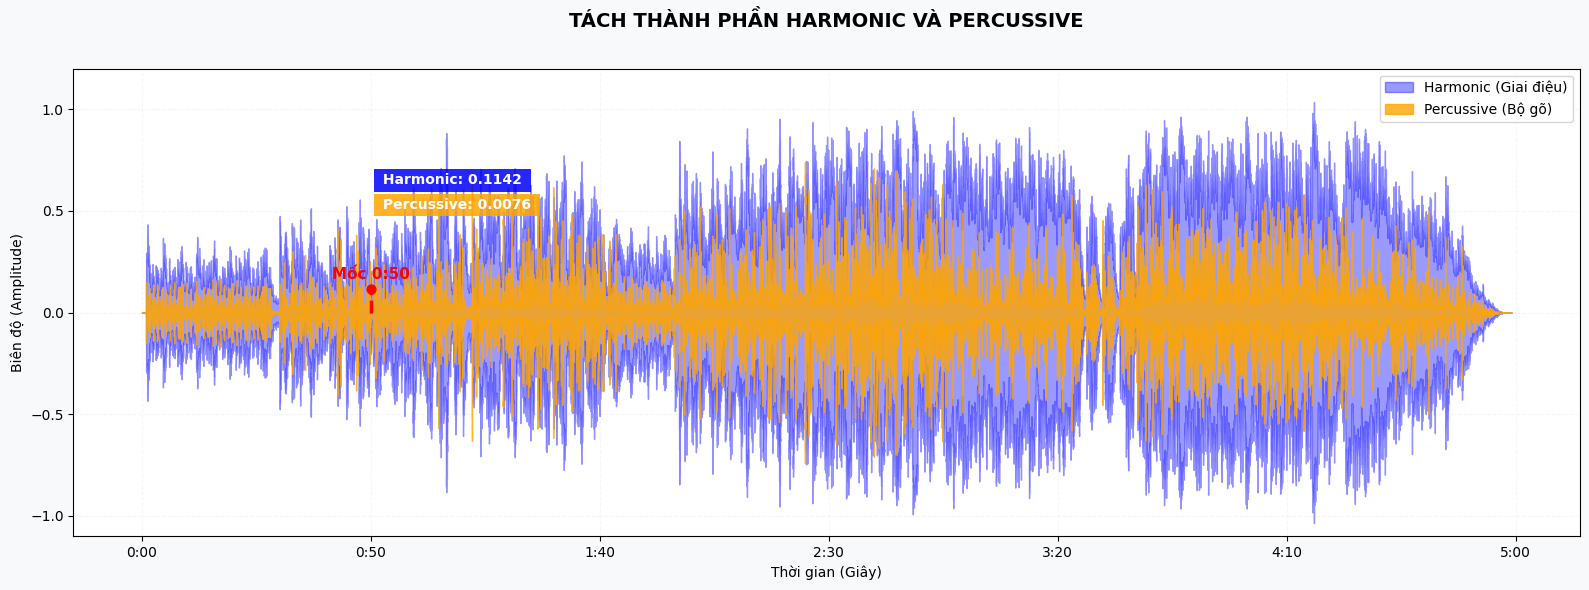

In [14]:
import matplotlib.pyplot as plt
import librosa.display

# Cấu hình màu sắc truyền thống theo báo cáo
color_h = 'blue'    # Harmonic - Xanh dương [cite: 336]
color_p = 'orange'  # Percussive - Cam [cite: 337]
color_line = 'red'  # Đường mốc thời gian

plt.figure(figsize=(16, 6), facecolor='#F8F9FA')

# 1. Vẽ sóng âm Harmonic và Percussive
librosa.display.waveshow(y_harmonic, sr=sr, alpha=0.4, label='Harmonic (Giai điệu)', color=color_h)
librosa.display.waveshow(y_percussive, sr=sr, alpha=0.8, label='Percussive (Bộ gõ)', color=color_p)

# 2. VẼ THANH ĐỎ NÉT ĐỨT CÓ ĐỘ CAO BẰNG ĐƯỜNG TÍN HIỆU (0.1142)
# Vẽ từ y=0 đến y=0.1142 tại x=50
plt.vlines(x=50, ymin=0, ymax=0.1142, color=color_line, linewidth=2.5, 
           linestyles='dashed', zorder=11)

# Thêm điểm chấm tại đỉnh để xác định tọa độ chính xác
plt.scatter(50, 0.1142, color=color_line, s=40, zorder=12)

# 3. CHÚ THÍCH CHO ĐƯỜNG MÀU ĐỎ VÀ GIÁ TRỊ
plt.text(50, 0.1142 + 0.05, 'Mốc 0:50', color=color_line, fontweight='bold', ha='center', fontsize=11)

# Hiển thị các ô giá trị gọn gàng, không dùng mũi tên
common_style = dict(fontweight='bold', color='white', fontsize=10)
plt.text(51.5, 0.65, f' Harmonic: 0.1142 ', va='center', 
         bbox=dict(boxstyle="square,pad=0.3", fc=color_h, ec="none", alpha=0.85), **common_style)
plt.text(51.5, 0.53, f' Percussive: 0.0076 ', va='center', 
         bbox=dict(boxstyle="square,pad=0.3", fc=color_p, ec="none", alpha=0.85), **common_style)

# Tinh chỉnh biểu đồ
plt.title('TÁCH THÀNH PHẦN HARMONIC VÀ PERCUSSIVE', fontsize=14, pad=30, fontweight='bold')
plt.xlabel('Thời gian (Giây)', fontsize=10)
plt.ylabel('Biên độ (Amplitude)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.1)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.ylim(-1.1, 1.2) 
plt.tight_layout()
plt.show()

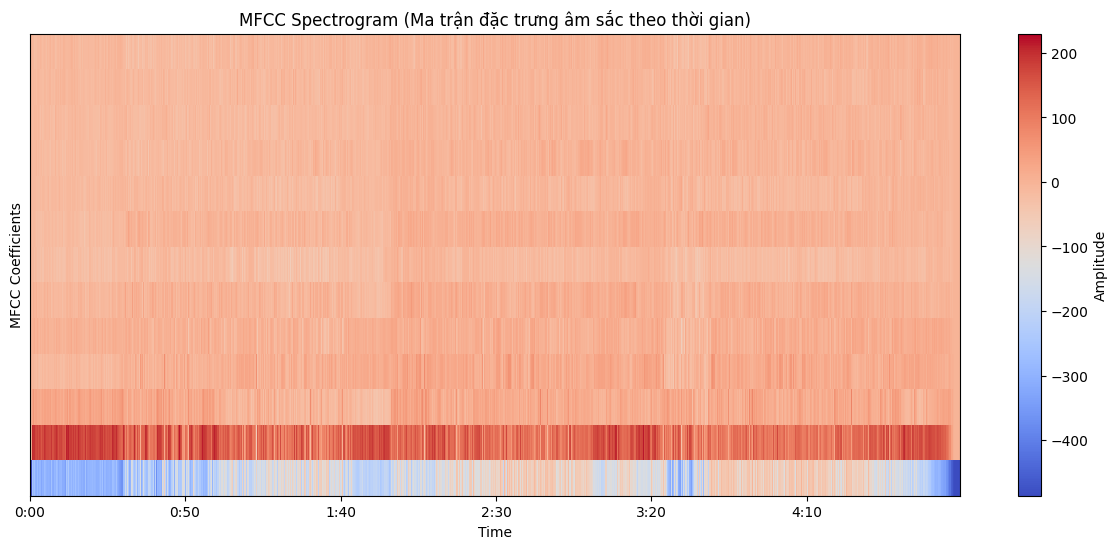

In [18]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(15, 6))
librosa.display.specshow(mfccs, x_axis='time', cmap='coolwarm')
plt.colorbar(label='Amplitude')
plt.title('MFCC Spectrogram (Ma trận đặc trưng âm sắc theo thời gian)')
plt.ylabel('MFCC Coefficients')
plt.show()

C:\Users\huyen\AppData\Local\Temp\ipykernel_11224\949242300.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo_val = float(tempo)


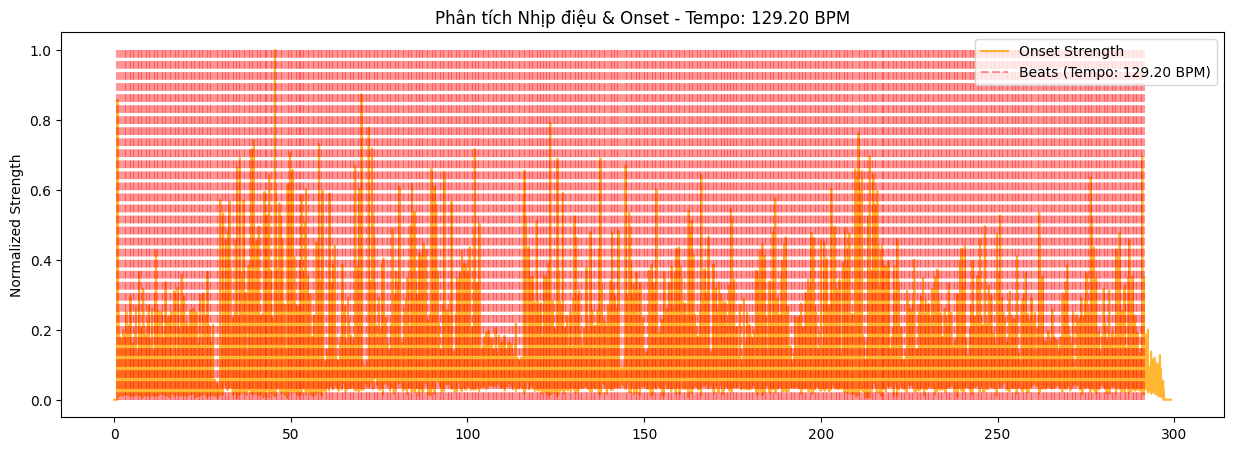

In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Nạp file âm thanh
y, sr = librosa.load('audio_final/Qua Khung Cửa Sổ.mp3')

# 1. Tính toán Onset và Tempo
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)

# SỬA LỖI TẠI ĐÂY: Ép kiểu tempo về float
tempo_val = float(tempo) 

beat_times = librosa.frames_to_time(beats, sr=sr)
times = librosa.times_like(onset_env, sr=sr)

plt.figure(figsize=(15, 5))
plt.plot(times, librosa.util.normalize(onset_env), label='Onset Strength', color='orange', alpha=0.8)
plt.vlines(beat_times, 0, 1, color='r', linestyle='--', alpha=0.4, label=f'Beats (Tempo: {tempo_val:.2f} BPM)')

plt.title(f'Phân tích Nhịp điệu & Onset - Tempo: {tempo_val:.2f} BPM')
plt.ylabel('Normalized Strength')
plt.legend()
plt.show()

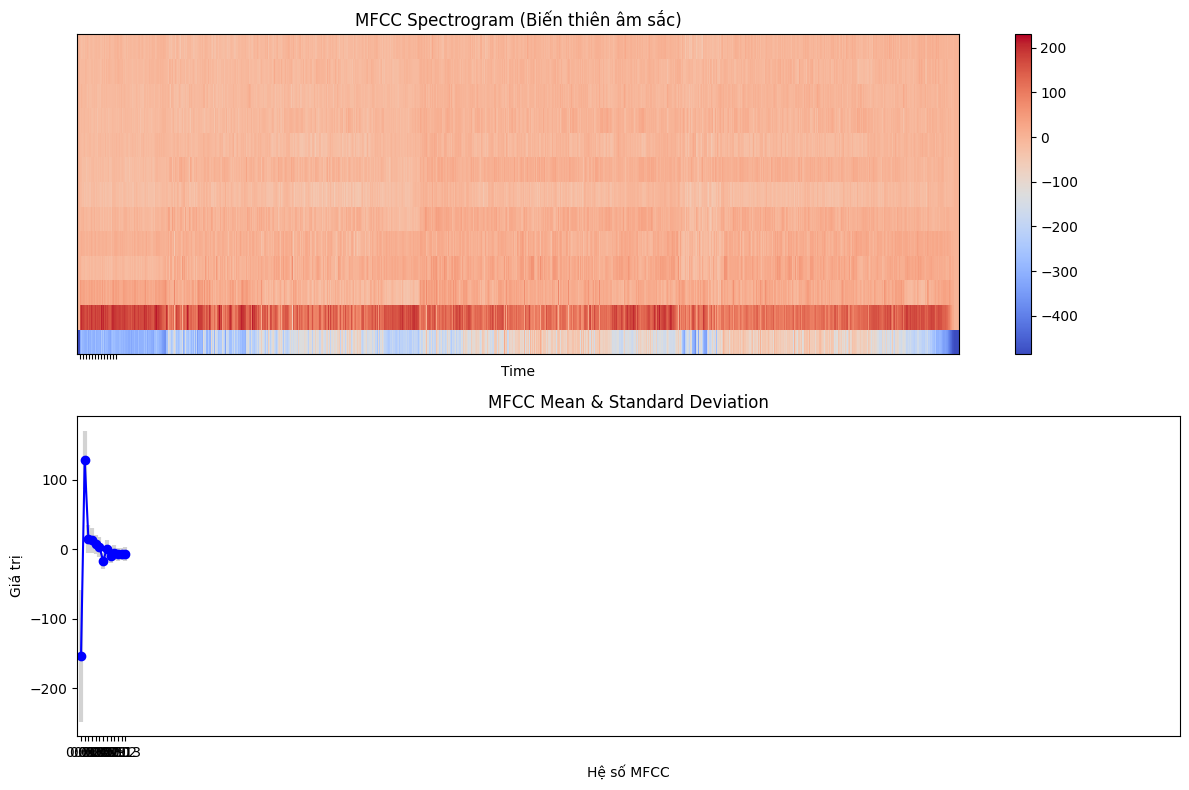

In [21]:
# Tính MFCC
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc_mean = np.mean(mfccs, axis=1)
mfcc_std = np.std(mfccs, axis=1)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Heatmap của MFCC theo thời gian
img = librosa.display.specshow(mfccs, x_axis='time', ax=ax[0], cmap='coolwarm')
ax[0].set(title='MFCC Spectrogram (Biến thiên âm sắc)')
fig.colorbar(img, ax=ax[0])

# Biểu đồ Mean & Std
ax[1].errorbar(range(1, 14), mfcc_mean, yerr=mfcc_std, fmt='-o', color='b', ecolor='lightgray', elinewidth=3, capsize=0)
ax[1].set(title='MFCC Mean & Standard Deviation', xlabel='Hệ số MFCC', ylabel='Giá trị')
ax[1].set_xticks(range(1, 14))

plt.tight_layout()
plt.show()

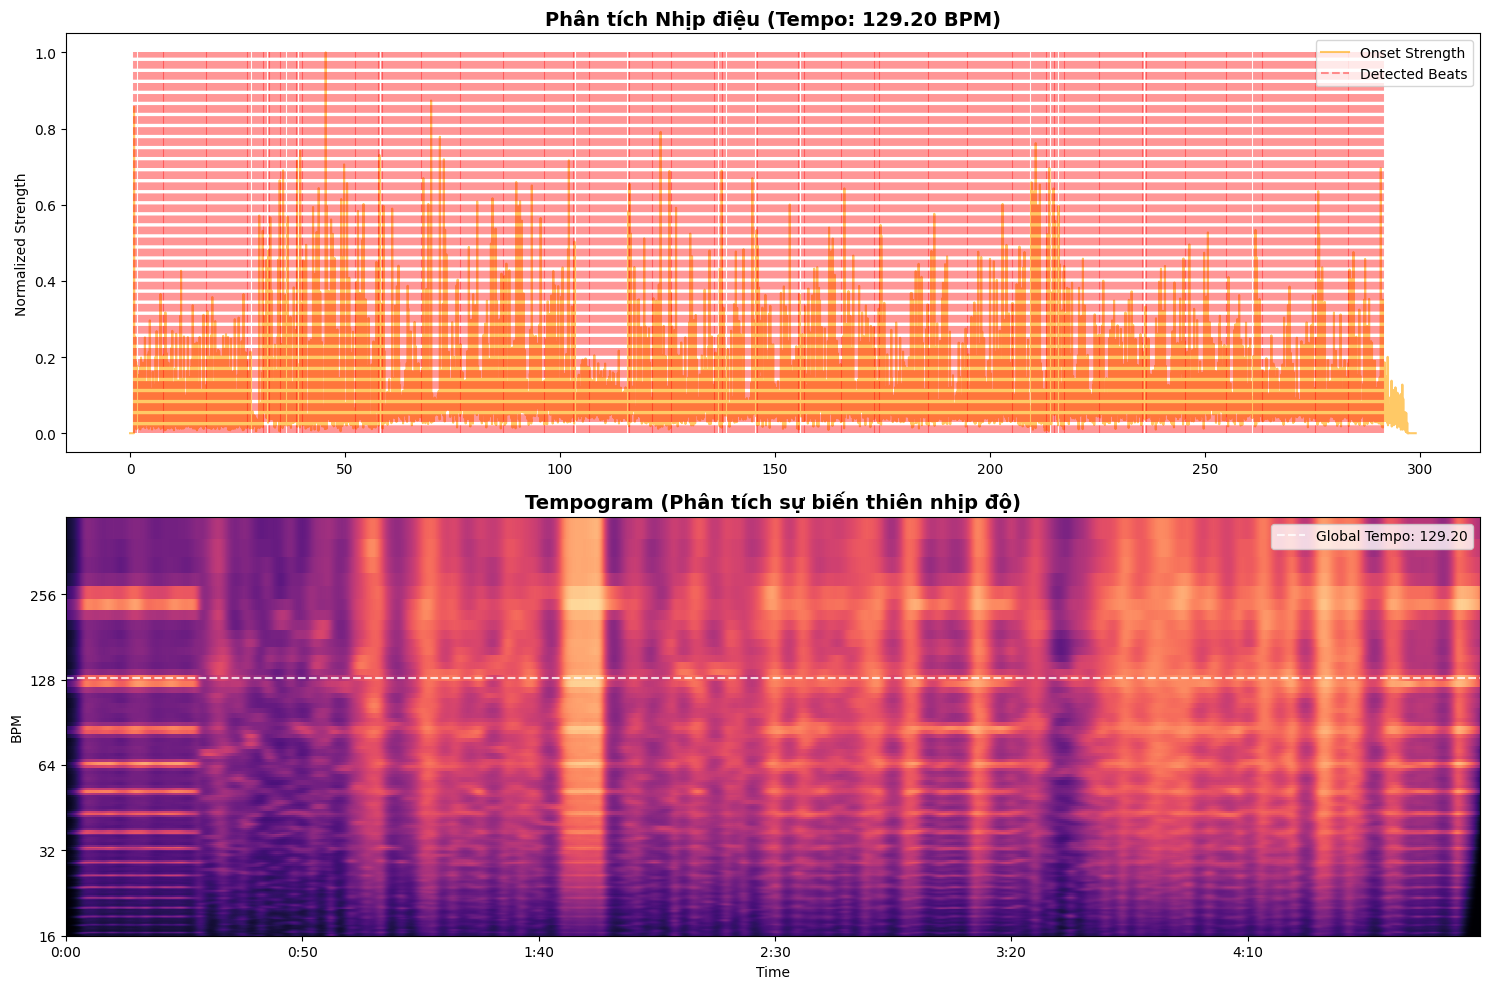

In [24]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Nạp file và cấu hình
audio_path = 'audio_final/Qua Khung Cửa Sổ.mp3'
y, sr = librosa.load(audio_path)

# 2. Tính toán Onset Strength (Lực nhấn âm thanh)
onset_env = librosa.onset.onset_strength(y=y, sr=sr)

# 3. Ước lượng Tempo và vị trí Beats
# Librosa 0.10+ trả về tempo là array, ta lấy .item() để có số thực
tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
tempo_val = tempo.item() if isinstance(tempo, np.ndarray) else tempo

# 4. Tính toán Tempogram (Phân tích nhịp độ cục bộ)
tempogram = librosa.feature.tempogram(onset_envelope=onset_env, sr=sr, hop_length=512)

# --- VẼ BIỂU ĐỒ CHUẨN ---
plt.figure(figsize=(15, 10))

# Panel 1: Onset Strength và Beats
plt.subplot(2, 1, 1)
times = librosa.times_like(onset_env, sr=sr)
plt.plot(times, librosa.util.normalize(onset_env), label='Onset Strength', color='orange', alpha=0.6)
beat_times = librosa.frames_to_time(beats, sr=sr)
plt.vlines(beat_times, 0, 1, color='r', linestyle='--', alpha=0.4, label='Detected Beats')
plt.title(f'Phân tích Nhịp điệu (Tempo: {tempo_val:.2f} BPM)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Strength')
plt.legend(loc='upper right')

# Panel 2: Tempogram (Sự ổn định của nhịp)
plt.subplot(2, 1, 2)
librosa.display.specshow(tempogram, sr=sr, x_axis='time', y_axis='tempo', cmap='magma')
plt.axhline(tempo_val, color='white', linestyle='--', alpha=0.8, label=f'Global Tempo: {tempo_val:.2f}')
plt.title('Tempogram (Phân tích sự biến thiên nhịp độ)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('tempo_onset_standard_analysis.png')
plt.show()

--- Đang phân tích lại: Qua Khung Cửa Sổ.mp3 ---
--- Đã hoàn thành xuất tất cả biểu đồ chuẩn khoa học ---


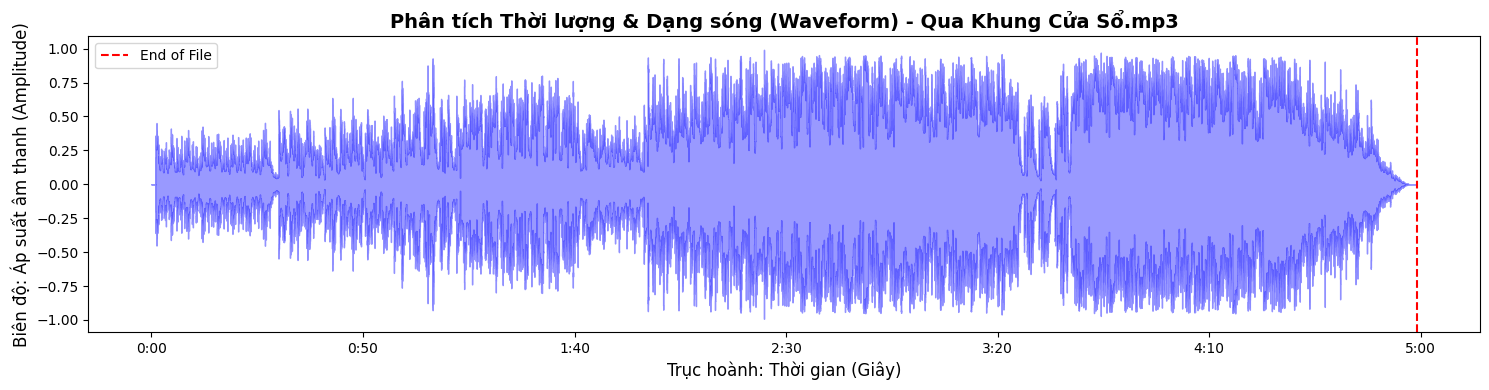

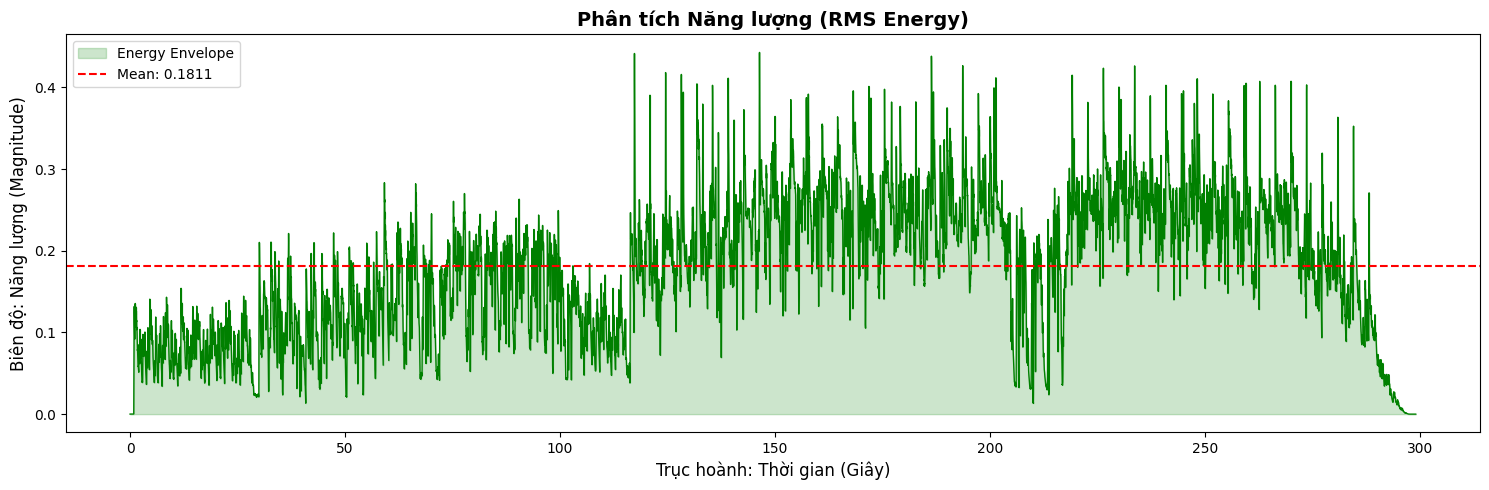

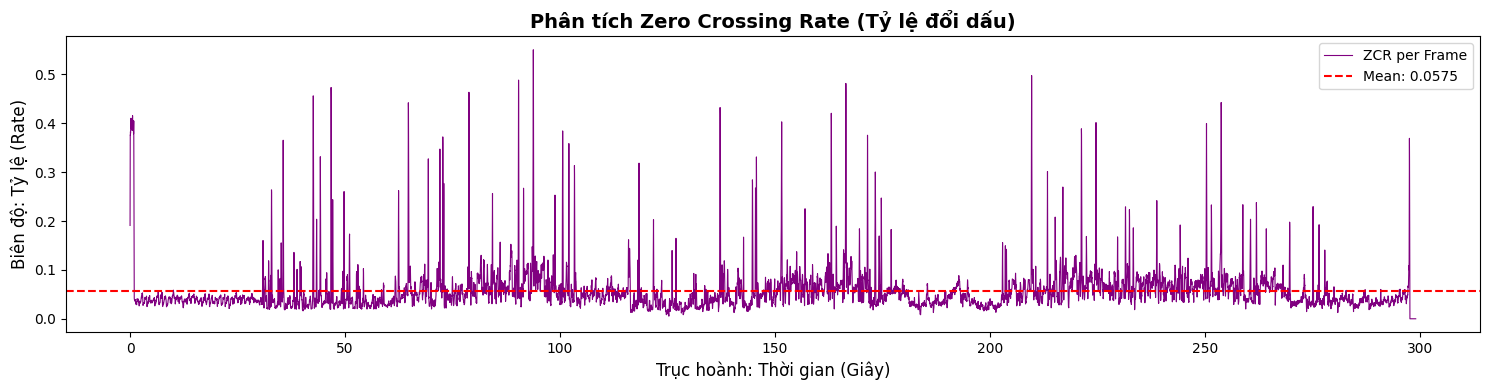

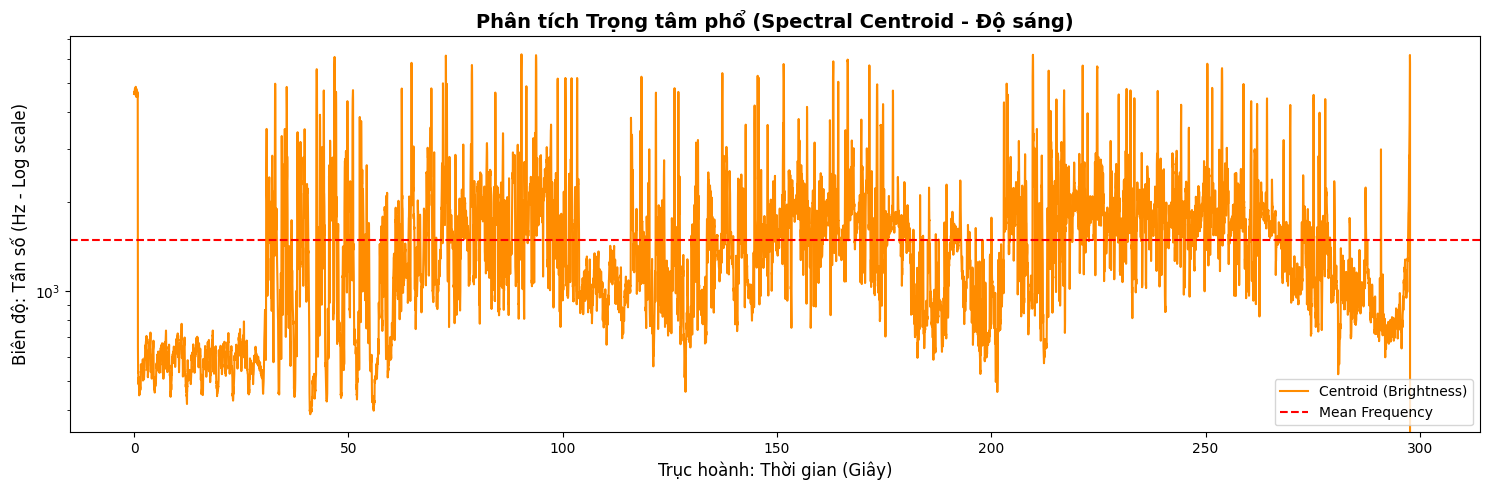

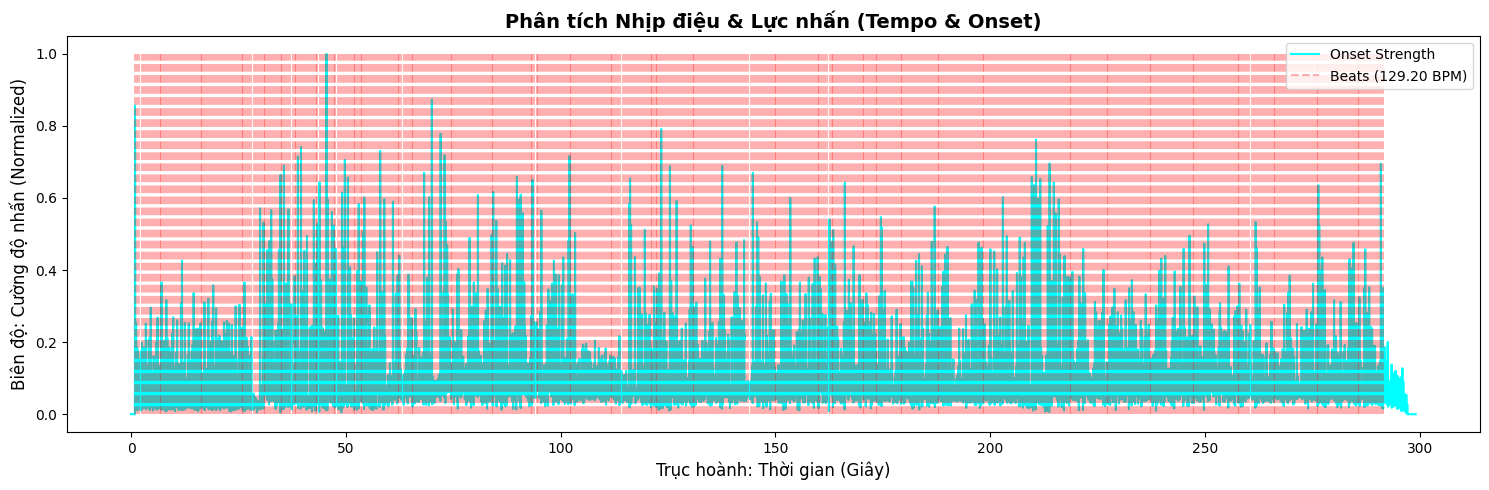

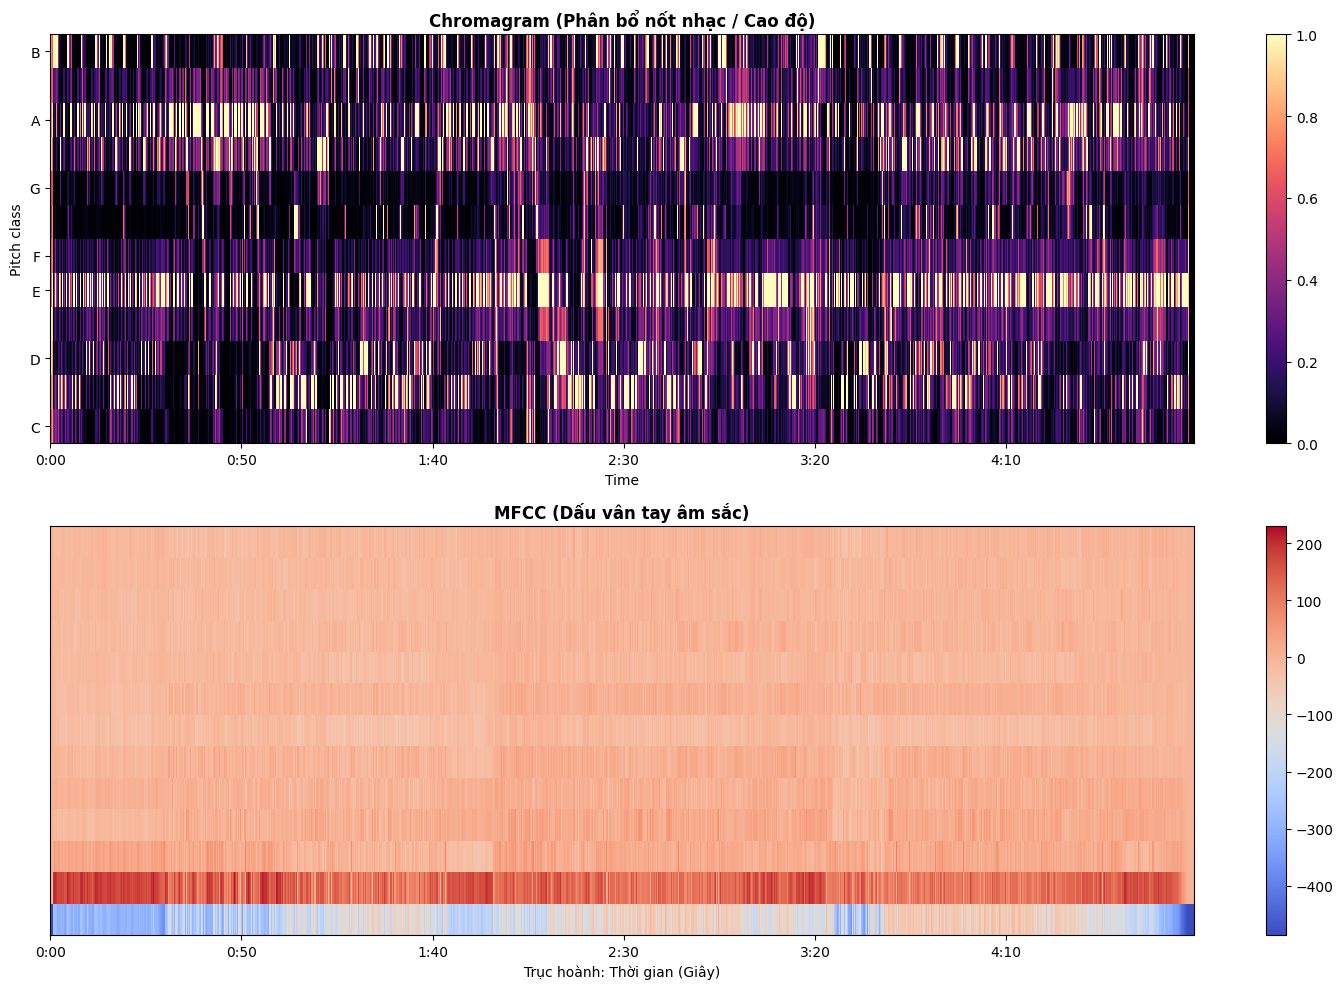

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ==========================================
# 1. CẤU HÌNH THÔNG SỐ & DỮ LIỆU
# ==========================================
AUDIO_PATH = 'audio_final/Qua Khung Cửa Sổ.mp3'
CSV_PATH = 'librosa_analysis.csv'
SONG_NAME = "Qua Khung Cửa Sổ.mp3"

# Nạp dữ liệu từ CSV để lấy mốc trung bình
df_csv = pd.read_csv(CSV_PATH)
song_stats = df_csv[df_csv['file_name'] == SONG_NAME].iloc[0]

# Chạy phân tích lại tín hiệu âm thanh
print(f"--- Đang phân tích lại: {SONG_NAME} ---")
y, sr = librosa.load(AUDIO_PATH)
y_harmonic, y_percussive = librosa.effects.hpss(y) # Tách Giai điệu/Bộ gõ

# ==========================================
# 2. BIỂU ĐỒ 1: DURATION (TIME DOMAIN)
# Công thức: Duration = N / sr
# ==========================================
plt.figure(figsize=(15, 4))
librosa.display.waveshow(y, sr=sr, color='blue', alpha=0.4)
plt.axvline(x=song_stats['duration_sec'], color='red', linestyle='--', label='End of File')
plt.title(f'Phân tích Thời lượng & Dạng sóng (Waveform) - {SONG_NAME}', fontsize=14, fontweight='bold')
plt.xlabel('Trục hoành: Thời gian (Giây)', fontsize=12)
plt.ylabel('Biên độ: Áp suất âm thanh (Amplitude)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('01_duration_waveform.png')

# ==========================================
# 3. BIỂU ĐỒ 2: RMS ENERGY (LOUDNESS)
# Công thức: RMS = sqrt(mean(x^2))
# ==========================================
rms = librosa.feature.rms(y=y)[0]
times_rms = librosa.times_like(rms, sr=sr)
plt.figure(figsize=(15, 5))
plt.fill_between(times_rms, rms, color='green', alpha=0.2, label='Energy Envelope')
plt.plot(times_rms, rms, color='green', linewidth=1)
plt.axhline(y=song_stats['rms_energy'], color='red', linestyle='--', label=f"Mean: {song_stats['rms_energy']:.4f}")
plt.title('Phân tích Năng lượng (RMS Energy)', fontsize=14, fontweight='bold')
plt.xlabel('Trục hoành: Thời gian (Giây)', fontsize=12)
plt.ylabel('Biên độ: Năng lượng (Magnitude)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('02_rms_energy.png')

# ==========================================
# 4. BIỂU ĐỒ 3: ZERO CROSSING RATE (NOISINESS)
# ==========================================
zcr = librosa.feature.zero_crossing_rate(y)[0]
plt.figure(figsize=(15, 4))
plt.plot(times_rms, zcr, color='purple', linewidth=0.8, label='ZCR per Frame')
plt.axhline(y=song_stats['zero_crossing_rate'], color='red', linestyle='--', label=f"Mean: {song_stats['zero_crossing_rate']:.4f}")
plt.title('Phân tích Zero Crossing Rate (Tỷ lệ đổi dấu)', fontsize=14, fontweight='bold')
plt.xlabel('Trục hoành: Thời gian (Giây)', fontsize=12)
plt.ylabel('Biên độ: Tỷ lệ (Rate)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('03_zcr.png')

# ==========================================
# 5. BIỂU ĐỒ 4: SPECTRAL CENTROID (BRIGHTNESS)
# ==========================================
cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
plt.figure(figsize=(15, 5))
plt.semilogy(times_rms, cent, color='darkorange', label='Centroid (Brightness)')
plt.axhline(y=song_stats['spectral_centroid_mean'], color='red', linestyle='--', label='Mean Frequency')
plt.title('Phân tích Trọng tâm phổ (Spectral Centroid - Độ sáng)', fontsize=14, fontweight='bold')
plt.xlabel('Trục hoành: Thời gian (Giây)', fontsize=12)
plt.ylabel('Biên độ: Tần số (Hz - Log scale)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('04_spectral_centroid.png')

# ==========================================
# 6. BIỂU ĐỒ 5: TEMPO & ONSET (RHYTHMIC)
# ==========================================
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
tempo_val = tempo.item() # Sửa lỗi numpy array
beat_times = librosa.frames_to_time(beats, sr=sr)

plt.figure(figsize=(15, 5))
plt.plot(times_rms, librosa.util.normalize(onset_env), label='Onset Strength', color='cyan')
plt.vlines(beat_times, 0, 1, color='r', linestyle='--', alpha=0.3, label=f'Beats ({tempo_val:.2f} BPM)')
plt.title('Phân tích Nhịp điệu & Lực nhấn (Tempo & Onset)', fontsize=14, fontweight='bold')
plt.xlabel('Trục hoành: Thời gian (Giây)', fontsize=12)
plt.ylabel('Biên độ: Cường độ nhấn (Normalized)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('05_tempo_onset.png')

# ==========================================
# 7. BIỂU ĐỒ 6: CHROMA & MFCC (HEATMAPS)
# ==========================================
chroma = librosa.feature.chroma_stft(y=y_harmonic, sr=sr)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

fig, ax = plt.subplots(2, 1, figsize=(15, 10))
# Chroma
img1 = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[0], cmap='magma')
ax[0].set_title('Chromagram (Phân bổ nốt nhạc / Cao độ)', fontsize=12, fontweight='bold')
plt.colorbar(img1, ax=ax[0])
# MFCC
img2 = librosa.display.specshow(mfcc, x_axis='time', ax=ax[1], cmap='coolwarm')
ax[1].set_title('MFCC (Dấu vân tay âm sắc)', fontsize=12, fontweight='bold')
plt.colorbar(img2, ax=ax[1])

plt.xlabel('Trục hoành: Thời gian (Giây)')
plt.tight_layout()
plt.savefig('06_chroma_mfcc.png')

print("--- Đã hoàn thành xuất tất cả biểu đồ chuẩn khoa học ---")

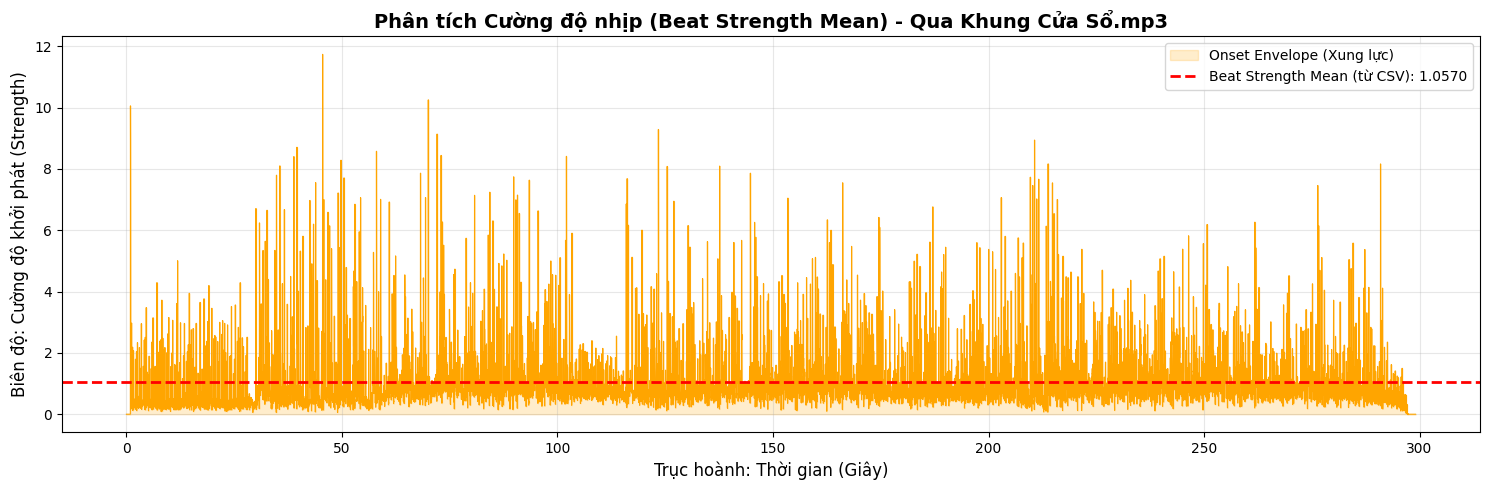

Giá trị Beat Strength Mean trích xuất: 1.057


In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Cấu hình đường dẫn
AUDIO_PATH = 'audio_final/Qua Khung Cửa Sổ.mp3'
CSV_PATH = 'librosa_analysis.csv'

# 2. Tải dữ liệu âm thanh và giá trị tham chiếu từ CSV
y, sr = librosa.load(AUDIO_PATH)
df_csv = pd.read_csv(CSV_PATH)
csv_val = df_csv[df_csv['file_name'] == "Qua Khung Cửa Sổ.mp3"]['beat_strength_mean'].values[0]

# 3. Tính toán Onset Envelope (Cơ sở của Beat Strength)
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(onset_env, sr=sr)

# 4. Vẽ biểu đồ theo chuẩn khoa học
plt.figure(figsize=(15, 5))

# Vẽ vùng biên độ Onset
plt.fill_between(times, onset_env, color='orange', alpha=0.2, label='Onset Envelope (Xung lực)')
plt.plot(times, onset_env, color='orange', linewidth=0.8)

# Vẽ đường trung bình (Beat Strength Mean) để đối chiếu
plt.axhline(y=csv_val, color='red', linestyle='--', linewidth=2, 
            label=f'Beat Strength Mean (từ CSV): {csv_val:.4f}')

# Tinh chỉnh trục và nhãn
plt.title('Phân tích Cường độ nhịp (Beat Strength Mean) - Qua Khung Cửa Sổ.mp3', fontsize=14, fontweight='bold')
plt.xlabel('Trục hoành: Thời gian (Giây)', fontsize=12)
plt.ylabel('Biên độ: Cường độ khởi phát (Strength)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

# Lưu file cho báo cáo
plt.savefig('beat_strength_analysis.png')
plt.show()

print(f"Giá trị Beat Strength Mean trích xuất: {csv_val}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lấy dữ liệu bài hát từ CSV
df = pd.read_csv('nlp_analysis_final.csv')
song_name = "Qua Khung Cửa Sổ.mp3"
data = df[df['file_name'].str.contains('Qua Khung Cửa Sổ', case=False, na=False)].iloc[0]

# Cấu hình chung cho biểu đồ
sns.set_style("whitegrid")

# --- HÌNH 1: PHÂN BỔ TỪ LOẠI (POS) ---
plt.figure(figsize=(8, 6))
pos_labels = ['Danh từ', 'Động từ', 'Tính từ']
pos_values = [data['noun_count'], data['verb_count'], data['adj_count']]
sns.barplot(x=pos_labels, y=pos_values, palette='magma')
plt.title(f'Phân bổ Từ loại: {song_name}', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng từ')
for i, v in enumerate(pos_values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=300)
plt.show()

# --- HÌNH 2: TỔNG SỐ TỪ (TOTAL WORDS) ---
plt.figure(figsize=(6, 6))
sns.barplot(x=['Tổng số từ'], y=[data['lyric_total_words']], color='#4e79a7')
plt.title(f'Quy mô văn bản: {song_name}', fontsize=14, fontweight='bold')
plt.text(0, data['lyric_total_words'] + 1, str(int(data['lyric_total_words'])), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('total_words.png', dpi=300)
plt.show()

# --- HÌNH 3: ĐỘ ĐA DẠNG TỪ VỰNG (LEXICAL DIVERSITY) ---
plt.figure(figsize=(6, 6))
div_val = data['lexical_diversity'] * 100
sns.barplot(x=['Độ đa dạng (%)'], y=[div_val], color='#f28e2b')
plt.title(f'Độ phong phú từ vựng: {song_name}', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.text(0, div_val + 2, f"{div_val:.2f}%", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lexical_diversity.png', dpi=300)
plt.show()

# --- HÌNH 4: ĐIỂM CẢM XÚC (SENTIMENT SCORE) ---
plt.figure(figsize=(6, 6))
score = data['sentiment_score']
color = '#e15759' if score < 0 else '#59a14f'
sns.barplot(x=['Sentiment Score'], y=[score], color=color)
plt.title(f'Chỉ số cảm xúc: {song_name}', fontsize=14, fontweight='bold')
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=1.5)
plt.text(0, score + (0.05 if score >= 0 else -0.1), f"{score:.4f}", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_score.png', dpi=300)
plt.show()

C:\Users\huyen\AppData\Local\Temp\ipykernel_1428\2649538872.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(song_name, sr=22050)
d:\Hit_songs_DA\.venv312\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'Qua Khung Cửa Sổ.mp3'

Device set to use cpu



KẾT QUẢ PHÂN TÍCH CHI TIẾT
File: Qua Khung Cửa Sổ.mp3

--- LEXICON (Từ điển) ---
Sentiment: negative
Score    : -0.0537
Conf     : 0.0537

--- PHOBERT (AI) ---
Sentiment: positive
Conf     : 0.9625
------------------------------
==> KẾT LUẬN CUỐI CÙNG: POSITIVE


C:\Users\huyen\AppData\Local\Temp\ipykernel_25208\2603694486.py:272: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


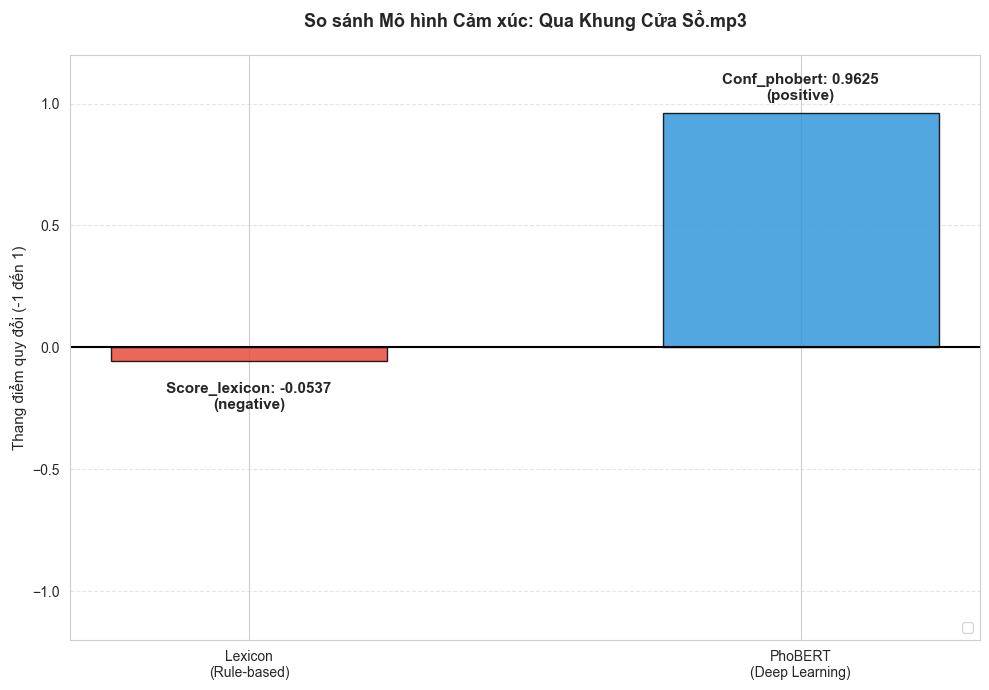

In [8]:

# ==============================================================================
# 1. CẤU HÌNH & KHỞI TẠO PHOBERT
# ==============================================================================


import re
import os
import csv
import pandas as pd
import numpy as np
from tqdm import tqdm
from mutagen.id3 import ID3
from underthesea import word_tokenize, pos_tag
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

# 1. KHỞI TẠO CÔNG CỤ (Giữ nguyên VADER của bạn và thêm PhoBERT)
vader_analyzer = SentimentIntensityAnalyzer()
# Khởi tạo PhoBERT một lần duy nhất
nlp_phobert = pipeline("sentiment-analysis", 
                       model="wonrax/phobert-base-vietnamese-sentiment", 
                       tokenizer="wonrax/phobert-base-vietnamese-sentiment")

# Cấu hình đường dẫn (Giữ nguyên của bạn)
FILE_PATH = 'audio_final\\Qua Khung Cửa Sổ.mp3'          

def get_lyrics_from_mp3(file_path):
    """Trích xuất lời bài hát từ thẻ USLT (Giữ nguyên 100% code của bạn)"""
    try:
        tags = ID3(file_path)
        lyrics = []
        for key in tags.keys():
            if key.startswith('USLT'):
                uslt = tags[key]
                lyrics.append(uslt.text if hasattr(uslt, 'text') else str(uslt))
        return '\n'.join(lyrics)
    except:
        return ""

def extract_lyric_features(text):
    """Trích xuất các đặc trưng ngôn ngữ."""
    if not text or not isinstance(text, str):
        return {'lyric_total_words': 0, 'lexical_diversity': 0.0, 'noun_count': 0, 'verb_count': 0, 'adj_count': 0}, ""
    
    text_lower = text.lower()
    text_clean = re.sub(r'\[.*?\]', ' ', text_lower)
    
    struct_keywords = r'\b(verse|ver|chorus|pre\s*chorus|pre-chorus|bridge|outro|intro|hook|drop|lyric|rap)[\s\d:]*'
    text_clean = re.sub(struct_keywords, ' ', text_clean)
    text_clean = re.sub(r'[^a-záàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệóòỏõọôốồổỗộơớờởỡợíìỉĩịúùủũụưứừửữựýỳỷỹỵđ\s]', ' ', text_clean)
    text_clean = re.sub(r'\s+', ' ', text_clean).strip()
    
    tokens = word_tokenize(text_clean)
    tags = pos_tag(text_clean)
    
    noun_count = sum(1 for _, tag in tags if tag in ['N', 'Np', 'Nc', 'Nu'])
    verb_count = sum(1 for _, tag in tags if tag in ['V', 'Vy'])
    adj_count = sum(1 for _, tag in tags if tag in ['A', 'Adj'])
    
    features = {
        'lyric_total_words': len(tokens),
        'lexical_diversity': round(len(set(tokens)) / len(tokens), 4) if len(tokens) > 0 else 0.0,
        'noun_count': noun_count,
        'verb_count': verb_count,
        'adj_count': adj_count
    }
    return features, text_clean

def analyze_lexicon(lyric_text): 
    """SENTIMENT ANALYSIS HYBRID V2: Lexicon Tiếng Việt + Slang + VADER"""
    if not lyric_text or len(lyric_text.strip()) == 0:
        return 'neutral', 0.0, 0.0

    # 1. TỪ ĐIỂN CẢM XÚC MỞ RỘNG (Đã bổ sung Slang & Nhạc trẻ)
    positive_words = [ # vui, tích cực
        'vui vẻ', 'hạnh phúc', 'phấn khởi',
        'yêu', 'thích', 'vui', 'hạnh phúc', 'đẹp', 'tuyệt', 'mơ', 'ước', 'cười',
        'rạng rỡ', 'ngọt ngào', 'nắng', 'xuân', 'hứng khởi', 'rộn ràng', 'tươi',
        'sáng', 'tình', 'hôn', 'ôm', 'bên nhau', 'mãi mãi', 'chung đôi', 'thương',
        'chill', 'phiêu', 'cuốn', 'dính', 'mê', 'ngất ngây', 'lâng lâng', 'thả thính',
        'bay', 'thăng hoa', 'bùng cháy', 'cháy', 'đỉnh', 'keo', 'lì', 'mlem',
        'bình yên', 'an yên', 'ấm', 'ấm áp', 'dịu dàng', 'êm', 'nhẹ nhàng',
        'thảnh thơi', 'tự do', 'chữa lành', 'an ủi', 'vỗ về', 'xinh', 'lung linh', 
        'lấp lánh', 'rực rỡ', 'tự hào', 'kiêu hãnh', 'thành công', 'vinh quang', 
        'nồng nàn', 'say đắm', 'vẹn tròn', 'đắm say', 'ngây ngất', 'nồng cháy',
        'phi thường'
    ]
    negative_words = [ # buồn, tiêu cực
        'buồn', 'đau', 'khóc', 'lỗi', 'sầu', 'thương đau', 'đau khổ', 'tê tái',
        'nghẹn', 'thắt', 'nhói', 'buốt', 'xót', 'đắng', 'cay', 'tủi', 'hờn',
        'oán', 'trách', 'hận', 'tiếc', 'day dứt', 'ám ảnh', 'toang', 'xu',
        'suy', 'lụy', 'trầm cảm', 'mệt', 'chán', 'nản', 'gãy', 'cút',
        'xa', 'mất', 'nhớ', 'quên', 'cô đơn', 'lẻ loi', 'vỡ', 'tan', 'chia',
        'lìa', 'giã từ', 'biệt ly', 'rời', 'bỏ', 'buông', 'lạc', 'trôi',
        'phôi pha', 'nhạt', 'phai', 'tàn', 'úa', 'héo', 'biến mất', 'cách xa',
        'lệ', 'nước mắt', 'ướt mi', 'hoen mi', 'đêm', 'mưa', 'bão', 'giông',
        'tối', 'đen', 'lạnh', 'giá', 'rét', 'vực', 'hố', 'mây đen', 'bóng tối',
        'chết', 'tử', 'gục', 'ngã', 'vỡ nát', 'vô vọng', 'tuyệt vọng'
    ]
    negation_words = [ # từ phủ định
        'không', 'chẳng', 'chả', 'đừng', 'chưa', 'thôi', 'hết', 'ngừng', 'dứt', 'đéo', 'đếch'
    ]
    
    # 2. Tính điểm VADER cho các từ tiếng Anh/Rap (Scale 0.3)
    vader_score = vader_analyzer.polarity_scores(lyric_text)['compound']
    
    # 3. Tính điểm Lexicon Tiếng Việt
    lyric_lower = lyric_text.lower()
    words = lyric_lower.split()
    pos_count = 0
    neg_count = 0
    neg_weight = 1.5 # Giảm để công bằng với nhạc vui

    for i, word in enumerate(words):
        context_before = words[max(0, i-2):i]
        has_negation = any(neg in context_before for neg in negation_words)
        
        if word in positive_words:
            if has_negation: neg_count += 1 * neg_weight
            else: pos_count += 1
        elif word in negative_words:
            if has_negation: pos_count += 0.5
            else: neg_count += 1 * neg_weight

    vn_ratio = (pos_count - neg_count) / len(words) if len(words) > 0 else 0
    
    # 4. Hybrid Score: Kết hợp VN Lexicon (70%) + VADER (30%)
    # Lưu ý: VADER score nằm từ -1 đến 1, cần scale nhẹ để không lấn át VN ratio
    final_score = (vn_ratio * 0.7) + (vader_score * 0.05 * 0.3)

    # 5. Phân loại với ngưỡng mới (Hạ thấp để bắt nhạc vui bị loãng từ)
    if final_score > 0.005: # Hạ từ 0.03 xuống 0.005
        sentiment = 'positive'
    elif final_score < -0.005:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
        
    return sentiment, round(final_score, 4), round(abs(final_score), 4)

def analyze_phobert(lyric_text):
    """Phương pháp PhoBERT Pipeline (Deep Learning)"""
    if not lyric_text: return 'neutral', 0.0
    chunk_size = 500
    chunks = [lyric_text[i:i + chunk_size] for i in range(0, len(lyric_text), chunk_size)]
    
    score_map = {'POS': 1, 'NEU': 0, 'NEG': -1}
    chunk_results = [nlp_phobert(c)[0] for c in chunks]
    
    avg_val = np.mean([score_map[r['label']] for r in chunk_results])
    avg_conf = np.mean([r['score'] for r in chunk_results])
    
    sentiment = 'positive' if avg_val > 0.2 else ('negative' if avg_val < -0.2 else 'neutral')
    return sentiment, round(avg_conf, 4)

def main():

    for _, row in tqdm(df.iterrows(), total=len(df)):
        fname = str(row['file_name'])
        
        fpath = os.path.join(FILE_PATH, fname)
        lyr_raw = get_lyrics_from_mp3(fpath)
        if not lyr_raw: continue

        feats, lyr_clean = extract_lyric_features(lyr_raw)
        
        s_lex, score_lex, cf_lex = analyze_lexicon(lyr_clean)
        s_pho, conf_pho = analyze_phobert(lyr_clean)
        
        if s_pho == s_lex:
            final_sent = s_pho
        # BƯỚC 2: Nếu mâu thuẫn, xét xem bên nào "tự tin" hơn
        elif conf_pho > 0.9: # AI cực kỳ chắc chắn về ngữ cảnh
            final_sent = s_pho
        elif cf_lex > 0.4:    # Từ điển có mật độ từ cảm xúc cực dày
            final_sent = s_lex
        # BƯỚC 3: Nếu cả hai đều phân vân -> Lấy theo AI (PhoBERT) làm chuẩn
        else:
            final_sent = s_pho
def main():
    if not os.path.exists(FILE_PATH):
        print(f"Lỗi: Không tìm thấy file {FILE_PATH}")
        return

    # 1. Lấy dữ liệu và làm sạch
    lyr_raw = get_lyrics_from_mp3(FILE_PATH)
    feats, lyr_clean = extract_lyric_features(lyr_raw)
    
    if not lyr_clean:
        print("Không trích xuất được lời bài hát.")
        return

    # 2. Phân tích song song
    s_lex, score_lex, cf_lex = analyze_lexicon(lyr_clean)
    s_pho, conf_pho = analyze_phobert(lyr_clean)
    
    # 3. Logic hợp nhất (Consensus Logic)
    if s_pho == s_lex:
        final_sent = s_pho
    elif conf_pho > 0.9: # AI rất chắc chắn
        final_sent = s_pho
    elif cf_lex > 0.4:   # Lexicon rất chắc chắn
        final_sent = s_lex
    else:
        final_sent = s_pho # Mặc định tin AI hơn

    # 4. IN KẾT QUẢ
    print("\n" + "="*60)
    print("KẾT QUẢ PHÂN TÍCH CHI TIẾT")
    print("="*60)
    print(f"File: {os.path.basename(FILE_PATH)}\n")
    print(f"--- LEXICON (Từ điển) ---")
    print(f"Sentiment: {s_lex}")
    print(f"Score    : {score_lex}")
    print(f"Conf     : {cf_lex}")
    print(f"\n--- PHOBERT (AI) ---")
    print(f"Sentiment: {s_pho}")
    print(f"Conf     : {conf_pho}")
    print("-" * 30)
    print(f"==> KẾT LUẬN CUỐI CÙNG: {final_sent.upper()}")
    print("="*60)

    # ==========================================================================
    # 5. VẼ BIỂU ĐỒ SO SÁNH (NÂNG CẤP)
    # ==========================================================================
    fig, ax = plt.subplots(figsize=(10, 7))
    
    models = ['Lexicon\n(Rule-based)', 'PhoBERT\n(Deep Learning)']
    
    # --- Xử lý dữ liệu vẽ ---
    # Quy đổi điểm số PhoBERT (Xác suất 0-1) sang thang (-1 đến 1) để vẽ
    pho_visual_score = 0
    if s_pho == 'positive': pho_visual_score = conf_pho
    elif s_pho == 'negative': pho_visual_score = -conf_pho
    
    # Mẹo nhỏ: Nếu điểm = 0 (Neutral), gán một giá trị cực nhỏ để cột vẫn hiện ra (để người xem thấy)
    visual_scores = [
        score_lex if abs(score_lex) > 0.001 else 0.02, 
        pho_visual_score if abs(pho_visual_score) > 0.001 else 0.02
    ]
    
    # --- Tô màu cột ---
    colors = []
    # Màu sắc dựa trên nhãn thực tế (s_lex, s_pho) chứ không phải điểm visual
    color_map = {'positive': '#3498db', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
    colors = [color_map.get(s_lex, '#95a5a6'), color_map.get(s_pho, '#95a5a6')]
    
    # Vẽ cột
    bars = ax.bar(models, visual_scores, color=colors, alpha=0.85, width=0.5, edgecolor='black')
    
    # --- Trang trí trục ---
    ax.axhline(0, color='black', linewidth=1.5) # Trục 0 đậm hơn
    ax.set_ylim(-1.2, 1.2) # Mở rộng trục Y để có chỗ cho text
    
    # --- Ghi chú thích lên cột ---
    # Cột Lexicon
    ax.text(0, visual_scores[0] + (0.1 if visual_scores[0]>=0 else -0.15), 
             f"Score_lexicon: {score_lex}\n({s_lex})", ha='center', va='center', fontweight='bold', fontsize=11)
    
    # Cột PhoBERT
    ax.text(1, visual_scores[1] + (0.1 if visual_scores[1]>=0 else -0.15), 
             f"Conf_phobert: {conf_pho}\n({s_pho})", ha='center', va='center', fontweight='bold', fontsize=11)
    
    # --- HIỂN THỊ KẾT LUẬN CUỐI CÙNG (QUAN TRỌNG) ---
    # Tạo màu cho khung kết luận dựa trên final_sent
    final_color = color_map.get(final_sent, 'gray')

    # Tiêu đề và nhãn
    plt.title(f"So sánh Mô hình Cảm xúc: {os.path.basename(FILE_PATH)}", fontsize=13, fontweight='bold', pad=20)
    plt.ylabel("Thang điểm quy đổi (-1 đến 1)", fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    main()

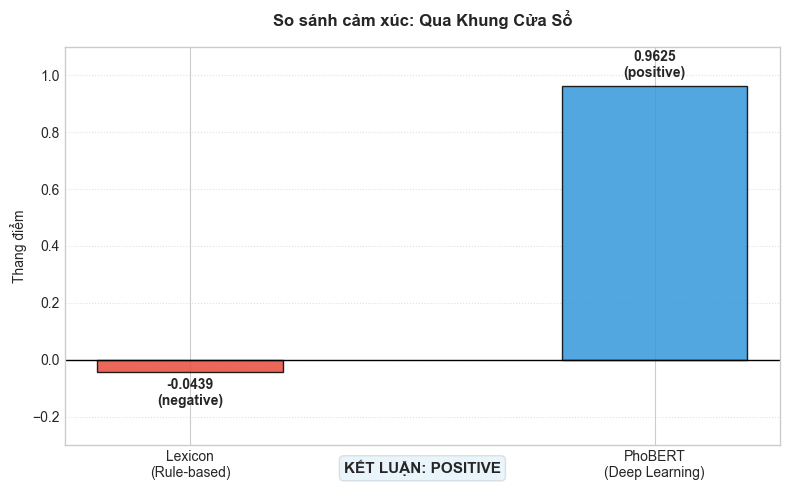

In [14]:
import matplotlib.pyplot as plt

# ==========================================
# DATA ĐẦU VÀO (Đã làm sạch khoảng trắng)
# ==========================================
sent_lexicon = "negative"
score_lexicon = -0.0439
sent_phobert = "positive"
conf_phobert = 0.9625
final_sentiment = "positive"
file_name = "Qua Khung Cửa Sổ"

def draw_optimized_chart():
    models = ['Lexicon\n(Rule-based)', 'PhoBERT\n(Deep Learning)']
    
    # Quy đổi điểm số để vẽ
    pho_visual_score = conf_phobert if sent_phobert == 'positive' else -conf_phobert
    visual_scores = [score_lexicon, pho_visual_score]
    
    # Màu sắc
    color_map = {'positive': '#3498db', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
    colors = [color_map.get(sent_lexicon), color_map.get(sent_phobert)]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(models, visual_scores, color=colors, alpha=0.85, width=0.4, edgecolor='black')
    
    # --- ĐIỀU CHỈNH TRỤC Y: Bỏ khoảng trắng từ -0.5 đến -1.0 ---
    ax.set_ylim(-0.3, 1.1) 
    ax.axhline(0, color='black', linewidth=1)
    
    # Ghi chú thông số trên mỗi cột
    for i, v in enumerate(visual_scores):
        label = score_lexicon if i == 0 else conf_phobert
        sentiment = sent_lexicon if i == 0 else sent_phobert
        va = 'bottom' if v > 0 else 'top'
        ax.text(i, v + (0.02 if v > 0 else -0.02), f"{label}\n({sentiment})", 
                ha='center', va=va, fontweight='bold', fontsize=10)

    # Khung kết luận cuối cùng
    final_color = color_map.get(final_sentiment)
    plt.text(0.5, -0.4, f"KẾT LUẬN: {final_sentiment.upper()}", 
             size=11, ha="center", fontweight='bold',
             bbox=dict(boxstyle="round", facecolor=final_color, alpha=0.1))

    plt.title(f"So sánh cảm xúc: {file_name}", fontsize=12, fontweight='bold', pad=15)
    plt.ylabel("Thang điểm")
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

draw_optimized_chart()

In [1]:
import librosa

# 1. Tải tệp âm thanh với tần số lấy mẫu sr=22050
y, sr = librosa.load("Qua Khung Cửa Sổ.mp3", sr=22050)

# 2. Tổng số mẫu N chính là độ dài của mảng y
N = len(y)
print(f"Tổng số mẫu (N): {N}")

C:\Users\huyen\AppData\Local\Temp\ipykernel_1428\3820091833.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load("Qua Khung Cửa Sổ.mp3", sr=22050)
d:\Hit_songs_DA\.venv312\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'Qua Khung Cửa Sổ.mp3'

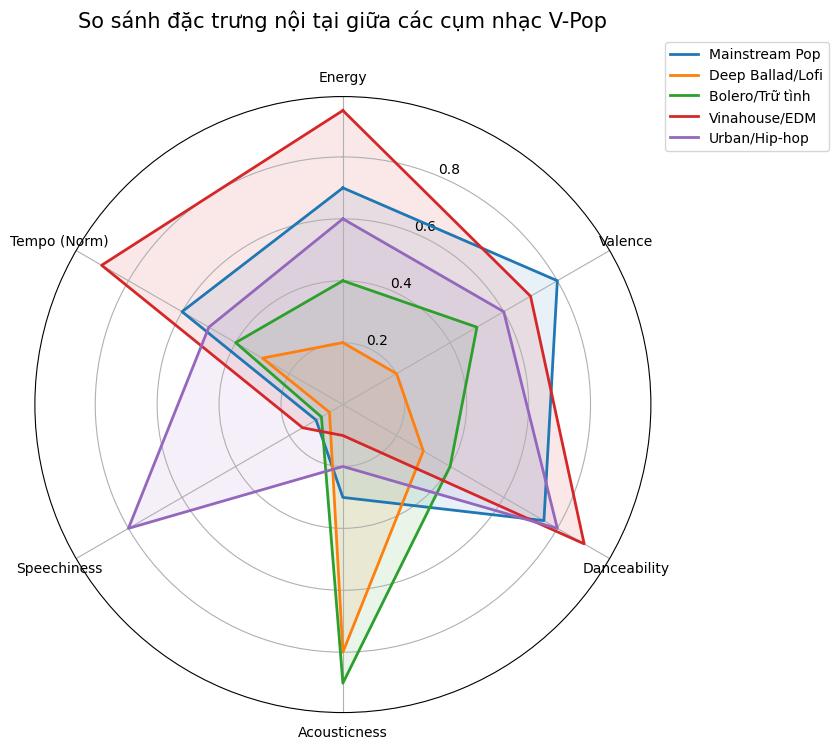

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa các đặc trưng (Features)
labels = ['Energy', 'Valence', 'Danceability', 'Acousticness', 'Speechiness', 'Tempo (Norm)']
num_vars = len(labels)

# 2. Dữ liệu giả lập cho 5 cụm (Dựa trên đặc trưng thực tế V-Pop)
# Thứ tự: [Energy, Valence, Danceability, Acousticness, Speechiness, Tempo]
clusters = {
    'Mainstream Pop': [0.7, 0.8, 0.75, 0.3, 0.1, 0.6],
    'Deep Ballad/Lofi': [0.2, 0.2, 0.3, 0.8, 0.05, 0.3],
    'Bolero/Trữ tình': [0.4, 0.5, 0.4, 0.9, 0.08, 0.4],
    'Vinahouse/EDM': [0.95, 0.7, 0.9, 0.1, 0.15, 0.9],
    'Urban/Hip-hop': [0.6, 0.6, 0.8, 0.2, 0.8, 0.5]
}

# 3. Vẽ biểu đồ
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Đóng vòng lặp biểu đồ

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, data in clusters.items():
    data += data[:1] # Đóng vòng lặp dữ liệu
    ax.plot(angles, data, linewidth=2, label=name)
    ax.fill(angles, data, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('So sánh đặc trưng nội tại giữa các cụm nhạc V-Pop', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()